# **California Housing - Red Neuronal vs. Regresión Lineal**

En este cuaderno se aborda un problema de regresión utilizando el dataset California Housing (incluido en Sklearn) con el objetivo de predecir el valor medio de las viviendas a partir de variables socioeconómicas y geográficas.

Se comparan dos enfoques de modelado: un modelo de regresión lineal, basado en el supuesto de relaciones lineales entre las variables, y una red neuronal (MLP), capaz de capturar relaciones no lineales más complejas.

El objetivo es analizar en qué medida la mayor flexibilidad de una red neuronal se traduce en una mejora real en la capacidad predictiva, evaluando métricas de desempeño que permitan justificar si un incremento en la complejidad del modelo redunda en un beneficio que lo justifique.

Para encarar el proyecto, se seguirá un flujo de trabajo estructurado: en primer lugar, se importará el dataset y se realizará un proceso de ETL (extracción, transformación y carga) para asegurar la calidad y consistencia de los datos. Luego, se analizará la correlación entre las variables predictoras y la variable objetivo, con el fin de seleccionar aquellas más representativas. Posteriormente, se aplicará un proceso de normalización sobre las variables seleccionadas. Finalmente, con el dataset preprocesado, se entrenarán y evaluarán ambos modelos —red neuronal MLP y regresión lineal— para comparar su desempeño.

---

Martin Nicolas Serafini

Mayo 2026

## **Importacion de librerias**

In [ ]:
# Manipulación de datos
import numpy as np
import pandas as pd
import itertools

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

# Métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gestión de archivos y sistema
import os
import joblib
from pathlib import Path

# Herramientas de entorno
from google.colab import files

## **Desarrollo**

### **ETL - Extracción, transformación y carga**

En esta sección se realiza la preparación inicial de los datos. Se valida la estructura del dataset, se verifica la ausencia de valores faltantes y se generan las transformaciones necesarias para dejar los datos listos para el análisis exploratorio y el modelado.

#### **Importacion de dataset**

El dataset contiene 3 bloques de datos
* data: matriz con las variables predictoras
* target: variable objetivo (precio de las viviendas)
* feature_names: nombres de las variables

In [ ]:
# Descarga y carga del dataset California Housing
california = fetch_california_housing()

# Conversión a DataFrame tomando los datos y los features como nombres de columnas
temp_df = pd.DataFrame(california.data, columns=california.feature_names)

# Se añade la variable objetivo (precio)
temp_df["MedHouseVal"] = california.target


In [ ]:
# Valores nulos por columna
temp_df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


##### **Conclusiones**
El dataframe no presenta valores null que deban ser tratados.

### **EDA - Análisis exploratorio**

En esta sección se realiza un análisis exploratorio de los datos con el objetivo de comprender la estructura del dataset, identificar posibles problemas (valores faltantes, outliers, distribuciones sesgadas) y analizar la relación entre las variables.

Se prestará especial atención a la correlación entre las variables predictoras y la variable objetivo (`MedHouseVal`), ya que esto permitirá seleccionar las variables más relevantes para el modelado y entender qué factores influyen en el precio de las viviendas.

In [ ]:
# Desempaqueto las dimensiones del dataframe
filas, columnas = temp_df.shape
print(f"El dataset tiene {filas} filas y {columnas} columnas.")

El dataset tiene 20640 filas y 9 columnas.


In [ ]:
# Veo nombre de columnas, formatos y valores null
print("\nTipos de datos:\n")
temp_df.info()


Tipos de datos:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


#### **Estadísticas descriptivas**

A continuación se presentan estadísticas resumen de las variables del dataset, incluyendo medidas de tendencia central, dispersión y valores extremos.

Esto permite identificar:
- posibles outliers
- diferencias de escala entre variables
- distribuciones sesgadas

In [ ]:
temp_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


##### **Conclusiones**

- **Diferencias de escala**:
  Variables como `Population` (máx ≈ 35682) y `AveOccup` (máx ≈ 1243) presentan valores muy superiores al resto, lo que indica la necesidad de normalización antes del modelado.

- **Presencia de outliers**:
  - `AveRooms` tiene un máximo de ≈ 142 cuando el valor medio es ≈ 5.4  
  - `AveBedrms` alcanza valores de ≈ 34  
  - `AveOccup` presenta valores extremadamente altos (máx ≈ 1243 vs media ≈ 3)

  Esto sugiere la existencia de valores atípicos que podrían afectar especialmente a modelos sensibles como la regresión lineal.

- **Distribución de la variable objetivo (`MedHouseVal`)**:
  - Rango: ≈ 0.15 a 5.0  
  - Se observa un posible **techo en el valor máximo**, lo cual es característico de este dataset (censura superior del precio).

- **Variables geográficas**:
  - `Latitude` y `Longitude` tienen rangos acotados pero relevantes  
  - Estas variables suelen introducir **relaciones no lineales**, lo que puede beneficiar a modelos como redes neuronales

El análisis descriptivo indica que:
- Es necesario aplicar técnicas de normalización
- Existen outliers que deben ser considerados
- Hay evidencia de posibles relaciones no lineales en los datos (por ejemplo entre los ingresos y los valores de las propiedades, inicialmente un incremento del primero influye en el segundo pero ese efecto tiende a disminuir, de ahi que no se comporte linealmente)

Esto justifica la comparación entre un modelo lineal y una red neuronal en las siguientes etapas.

#### **Distribución de variables**

Se analizan las distribuciones de las variables para identificar sesgos, diferencias de escala y posibles comportamientos no normales.

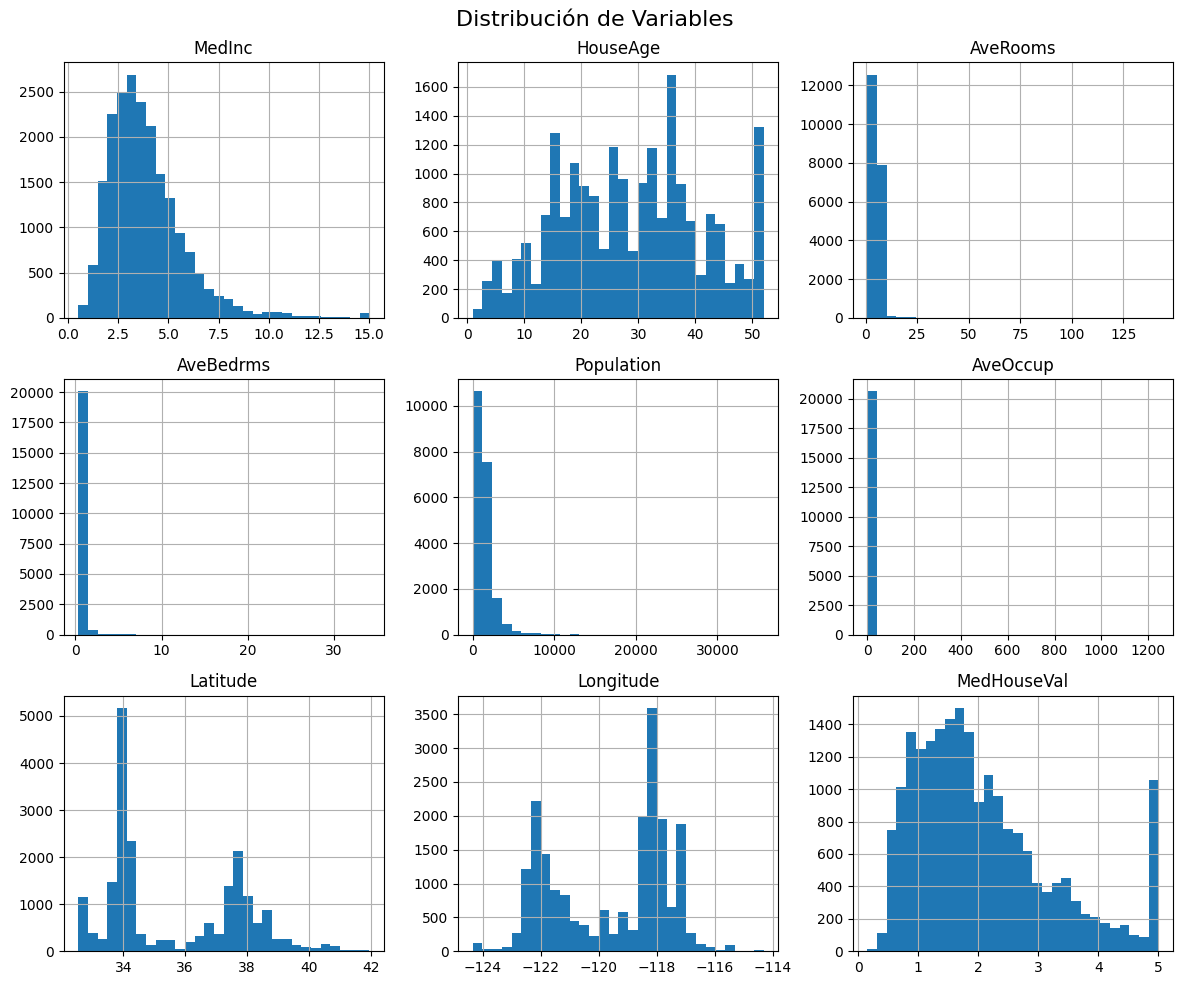

In [ ]:
# Distribución de variables (histogramas)

temp_df.hist(bins=30, figsize=(12,10))
plt.suptitle("Distribución de Variables", fontsize=16)
plt.tight_layout()
plt.show()

##### **Conclusiones**

El análisis de los histogramas permite extraer varias conclusiones relevantes sobre la estructura del dataset y su impacto en el modelado.

1. **Presencia de asimetrías**

Se observa que varias variables presentan asimetría positiva (cola hacia la derecha):

- `AveRooms`
- `AveBedrms`
- `Population`
- `AveOccup`
- `MedInc` (en menor medida)

Esto indica que:
- La mayoría de los valores se concentra en rangos bajos
- Existen pocos valores extremadamente altos

Este comportamiento puede afectar modelos como la regresión lineal, ya que estos son sensibles a distribuciones no normales.

---

2. **Evidencia de outliers**

Las distribuciones confirman la presencia de valores extremos:

- `AveOccup` muestra valores muy alejados del grueso de la distribución  
- `Population` presenta una cola larga con valores elevados  
- `AveRooms` y `AveBedrms` contienen valores poco realistas  

Esto refuerza la necesidad de:
- Aplicar filtros o transformaciones
- Utilizar técnicas robustas en el preprocesamiento

---

3. **Diferencias de escala entre variables**

Se observan rangos muy distintos entre variables:

- `Population` → valores en miles  
- `AveRooms` → valores en decenas  
- `Latitude` / `Longitude` → rangos acotados  

Esto implica que:
- Los modelos basados en gradiente (como redes neuronales) requieren normalización
- La regresión lineal puede beneficiarse de un escalado adecuado

---

4. **Variables con distribución más estable**

Algunas variables presentan distribuciones más equilibradas:

- `HouseAge`
- `Latitude`
- `Longitude`

Estas variables:
- No presentan outliers extremos
- Son más estables desde el punto de vista estadístico

---

5. **Distribución de la variable objetivo (`MedHouseVal`)**

Se observa que:
- La variable presenta cierta asimetría
- Existe una acumulación en el valor máximo (≈ 5)

Esto sugiere la presencia de un límite superior en los datos, lo cual puede afectar la capacidad de los modelos para aprender valores mas altos.



#### **Detección de outliers**

Se utilizan boxplots para identificar valores atípicos que pueden afectar el desempeño de los modelos, especialmente en regresión lineal.

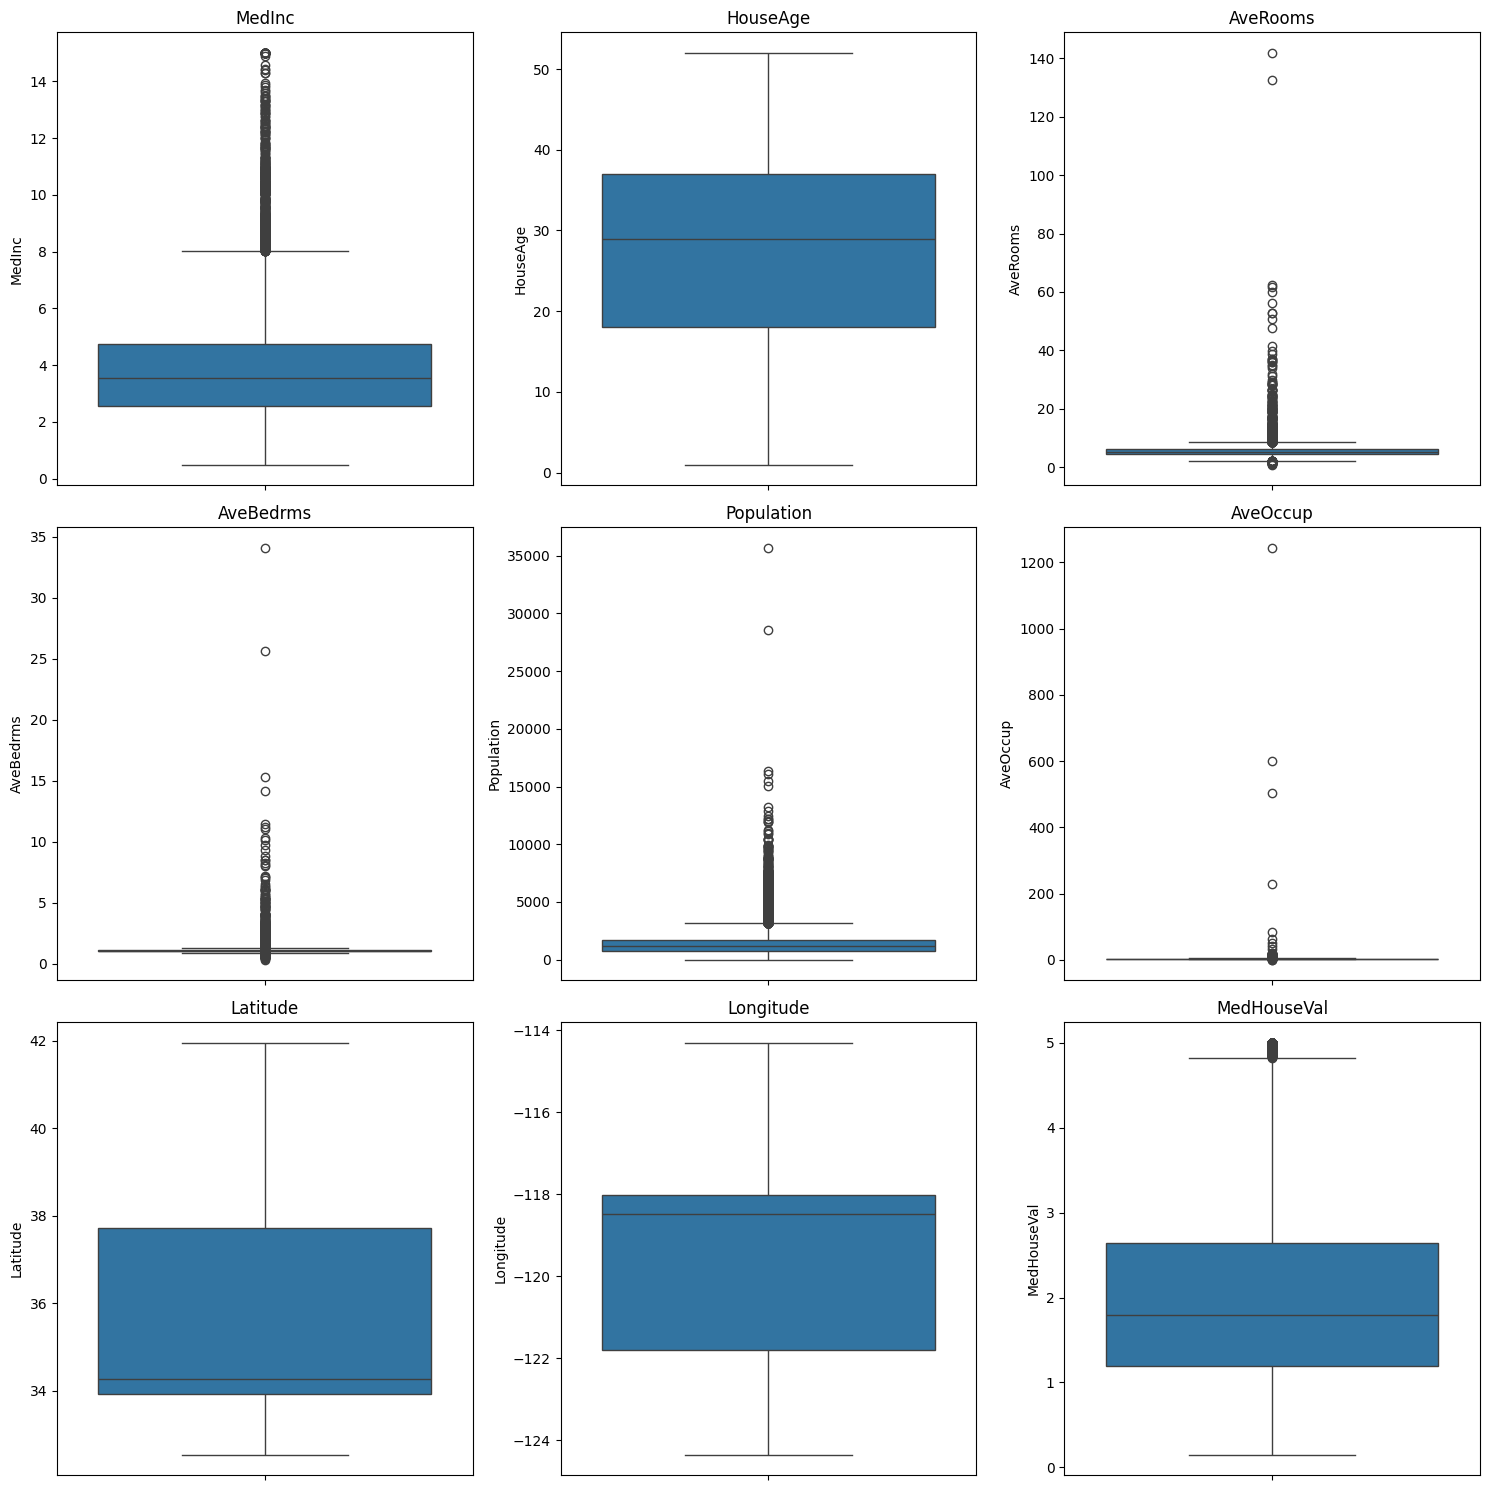

In [ ]:
# Detección de outliers mediante boxplots

columnas = temp_df.columns

n_cols = 3
n_rows = int(np.ceil(len(columnas) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(columnas, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=temp_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

##### **Conclusiones**

El análisis de los boxplots permite identificar de forma clara la presencia, magnitud y distribución de los valores atípicos (outliers) en cada variable.

1. **Variables con alta presencia de outliers**

Se observan outliers significativos en:

- `AveOccup`
- `Population`
- `AveRooms`
- `AveBedrms`

En estos casos:
- La mayoría de los datos está concentrada en un rango muy acotado
- Existe una gran cantidad de valores extremos alejados de la mediana

Particularmente:
- `AveOccup` presenta valores extremadamente elevados respecto a su mediana (~3)
- `Population` muestra una dispersión amplia con numerosos valores altos
- `AveRooms` y `AveBedrms` contienen valores poco consistentes con el contexto del problema

Esto sugiere que:
- Existen observaciones atípicas que pueden distorsionar el entrenamiento
- Es recomendable aplicar filtros o técnicas robustas

---

2. **Variables con comportamiento más estable**

Las siguientes variables presentan distribuciones más controladas:

- `HouseAge`
- `Latitude`
- `Longitude`

Características:
- Menor cantidad de outliers
- Rangos acotados
- Mediana representativa

Estas variables son más confiables desde el punto de vista estadístico y no requieren tratamiento especial.

---

3. **Variable de ingreso (`MedInc`)**

- Presenta algunos outliers superiores
- Sin embargo, estos valores pueden ser válidos en términos económicos

Por lo tanto:
- No necesariamente deben eliminarse
- Pueden aportar información relevante al modelo

---

4. **Variable objetivo (`MedHouseVal`)**

- Se observa un límite superior claro
- Los valores máximos están concentrados

Esto refuerza la idea de que existe una censura en el dataset, lo cual puede afectar la capacidad predictiva en valores altos.

---

5. **Implicancias para el modelado**

El análisis de boxplots permite concluir que:

- Los modelos lineales serán sensibles a estos outliers
- Las redes neuronales también pueden verse afectadas en el proceso de entrenamiento
- Seria recomendable:
  - Eliminar o limitar valores extremos
  - Aplicar escalado o normalización de datos

#### **Análisis de correlación (Dataset Completo)**

Se evalúa la relación entre las variables mediante el coeficiente de correlación de Pearson, con el objetivo de identificar predictores relevantes y posibles problemas de multicolinealidad.

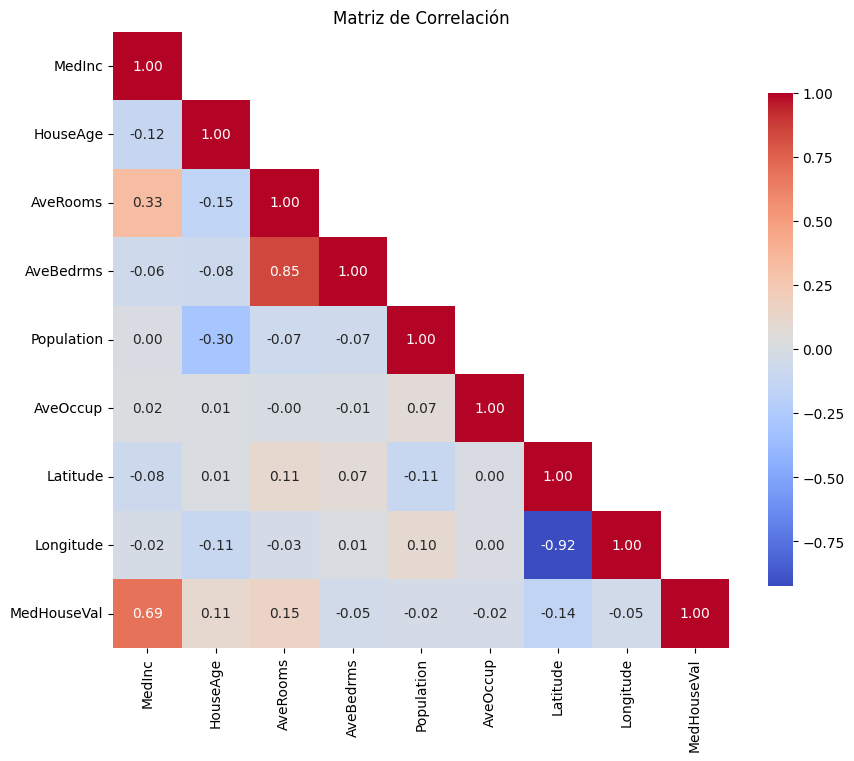

In [ ]:
# Análisis de correlación

# Calculo matriz de correlación
corr_matrix = temp_df.corr()

# Creo máscara para ocultar triángulo superior
mascara =np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Visualización
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de Correlación")
plt.show()

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


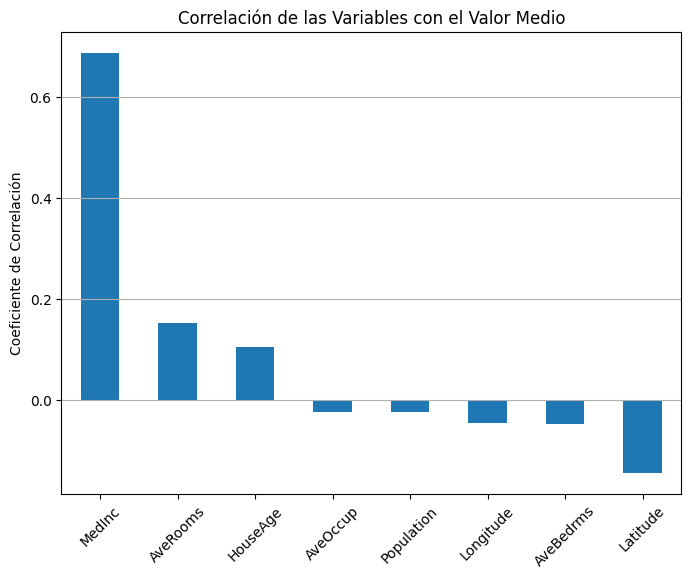

In [ ]:
# Correlación con la variable objetivo (MedHouseVal)

# Calcular correlaciones
corr_target = temp_df.corr()["MedHouseVal"].sort_values(ascending=False)

# Mostrar valores
print(corr_target)

# Visualización
plt.figure(figsize=(8,6))
corr_target.drop("MedHouseVal").plot(kind="bar")

plt.title("Correlación de las Variables con el Valor Medio")
plt.ylabel("Coeficiente de Correlación")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

##### **Conclusiones**

La correlación mide relaciones lineales. Si una variable tiene baja correlación, no significa que no tenga valor, sino que su relación puede ser más compleja.

Variable con mayor poder predictivo

- `MedInc` presenta una correlación de aproximadamente 0.69 con el precio de las viviendas.

Esto indica que:
- Es la variable más influyente del dataset
- Existe una relación lineal fuerte entre ingreso medio y valor de la vivienda

---

2. Variables con baja correlación lineal

Las siguientes variables presentan correlaciones cercanas a cero con la variable objetivo:

- `Population`
- `AveOccup`

Esto sugiere que:
- No tienen una relación lineal significativa con el precio
- Podrían tener baja relevancia en modelos lineales

---

3. Variables con posible comportamiento no lineal

- `Latitude`
- `Longitude`

Si bien presentan baja correlación lineal, estas variables:
- Contienen información geográfica relevante
- Pueden influir en el precio de forma no lineal

Esto las hace especialmente útiles para modelos más complejos, como redes neuronales.

---

4. Presencia de multicolinealidad

Se observa una correlación alta entre:

- `AveRooms` y `AveBedrms` (≈ 0.85)

Esto indica que:
- Ambas variables contienen información redundante
- Existe multicolinealidad, lo cual puede afectar negativamente a modelos como la regresión lineal

---

5. Selección de variables

Al comparar su relación con la variable objetivo:

- `AveRooms` → correlación ≈ 0.15  
- `AveBedrms` → correlación ≈ -0.05  

Se concluye que:
- `AveRooms` aporta mayor información
- `AveBedrms` puede ser eliminada sin pérdida significativa de capacidad predictiva


### **Preprocesamiento de datos**

En esta sección se aplican transformaciones sobre el dataset a partir de los hallazgos del análisis exploratorio. Esto incluye la eliminación de valores atípicos y la selección de variables, con el objetivo de mejorar la calidad de los datos y el desempeño de los modelos.

#### **Selección de variables**

A partir del análisis exploratorio y de correlación, se procede a realizar una selección de variables con el objetivo de reducir redundancia y ruido en el dataset.

En primer lugar, se identifica una alta correlación entre `AveRooms` y `AveBedrms` (≈ 0.85), lo que indica la presencia de multicolinealidad. Dado que `AveRooms` presenta una mayor correlación con la variable objetivo (`MedHouseVal`), se decide conservar esta variable y eliminar `AveBedrms`.

Por otro lado, la variable `AveOccup` presenta una correlación prácticamente nula con el precio, además de una alta dispersión y presencia de outliers, lo que sugiere un comportamiento ruidoso. Se opta por eliminarla del modelo no porque su correlacion con el valor sea baja sino porque del analisis de la misma surge que la cantidad de ocupantes de un inmueble no impacta en el valor del mismo (baja correlación no implica irrelevancia).

En el caso de `Population`, si bien su correlación lineal con la variable objetivo es baja, se decide conservarla debido a que puede aportar información contextual relacionada con la localización de las propiedades, especialmente en combinación con variables geográficas como `Latitude` y `Longitude`.

In [ ]:
# Selección de variables (basado en EDA)
df_model = temp_df.copy()

# Elimino variables
df_model = df_model.drop(columns=["AveBedrms", "AveOccup"])


#### **Tratamiento de outliers en `AveRooms`**

A partir del análisis exploratorio, se detecta que la variable `AveRooms` presenta valores extremadamente altos en comparación con su distribución central.

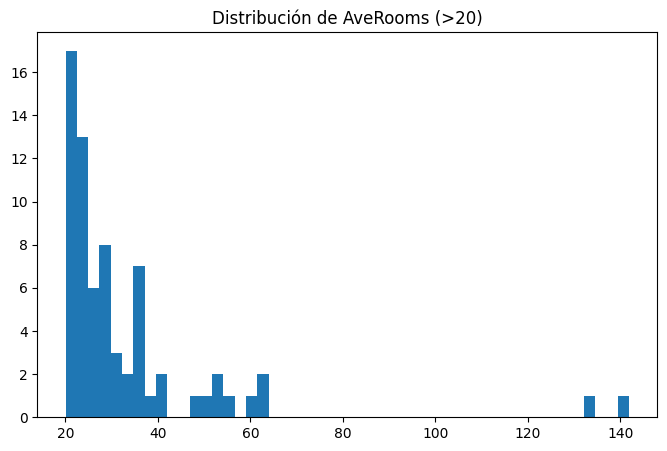

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(temp_df[df_model["AveRooms"] > 20]["AveRooms"], bins=50)
plt.title("Distribución de AveRooms (>20)")
plt.show()

In [ ]:
df_model.sort_values(by="AveRooms", ascending=False).head(10)

,MedInc,HouseAge,AveRooms,Population,Latitude,Longitude,MedHouseVal
1914,1.8750,33.0,141.909091,30.0,38.91,-120.10,5.00001
1979,4.6250,34.0,132.533333,36.0,38.80,-120.08,1.62500
12447,1.6154,17.0,62.422222,83.0,33.97,-114.49,0.87500
1913,4.0714,19.0,61.812500,112.0,39.01,-120.06,4.37500
11862,2.6250,25.0,59.875000,28.0,40.27,-121.25,0.67500
1912,4.9750,16.0,56.269231,54.0,39.01,-120.16,2.06300
9676,3.2431,14.0,52.848214,265.0,37.64,-119.02,2.21400
11707,1.1912,22.0,52.690476,98.0,39.15,-120.06,1.70000
2395,3.8750,23.0,50.837838,64.0,37.12,-119.34,1.25000
1240,3.1250,11.0,47.515152,82.0,38.42,-120.19,0.77500


In [ ]:
df_model["AveRooms"].quantile([0.90, 0.95, 0.99, 0.999])

,AveRooms
0.900,6.961188
0.950,7.640247
0.990,10.357033
0.999,34.199698


El análisis detallado de la variable `AveRooms` revela la presencia de valores extremadamente elevados en relación con su distribución central. Mientras que la mayoría de los valores se concentra por debajo de 10, existen observaciones que superan ampliamente este rango, alcanzando valores superiores a 140.

Adicionalmente, estos valores extremos no guardan coherencia con la variable objetivo (`MedHouseVal`), ya que se observan propiedades con un número muy elevado de habitaciones promedio pero con precios relativamente bajos.

En este contexto, no se trata únicamente de outliers estadísticos, sino de inconsistencias derivadas de la construcción de la variable. Por lo tanto, se decide aplicar un recorte sobre `AveRooms`, eliminando aquellos valores que exceden un umbral razonable, con el objetivo de mejorar la calidad del dataset y la robustez de los modelos.

In [ ]:
df_model = df_model[df_model["AveRooms"] < 20]

#### **Preparación de datos para el modelado**

Una vez finalizado el análisis exploratorio y aplicado el proceso de limpieza de datos, se procede a preparar el dataset para el entrenamiento de los modelos.

##### **Separación de variables predictoras y variable objetivo**

En esta etapa se separa el dataset en:
- Variables predictoras (X): conjunto de características que se utilizarán como entrada del modelo  
- Variable objetivo (y): variable que se desea predecir (`MedHouseVal`)


In [ ]:
# Separo de variables

X = df_model.drop(columns=["MedHouseVal"])
y = df_model["MedHouseVal"]

print("Predictores (X):", X.shape)
print("Objetivo (y):", y.shape)

Predictores (X): (20571, 6)
Objetivo (y): (20571,)


##### **División del dataset en conjuntos de entrenamiento y prueba**

El objetivo del split no es solo separar datos, sino garantizar una evaluación justa y reproducible del modelo.

**Parametros importantes:**
* test_size: Define cuánto del dataset se usa para evaluación.
* random_state: Fija la semilla aleatoria.
  * Asegura que siempre se obtenga la misma partición
  * Permite comparar modelos en igualdad de condiciones
* shuffle: Mezcla de datos
* stratify: Se utiliza para asegurarse una distribución de la variable objetivo. Este parametro es fundamental en problemas de clasificación para asegurar una división balanceada de los datos. En regresión su uso no es directo y dependera de cada caso (en este caso se descarta su uso).

In [ ]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16456, 6)
X_test: (4115, 6)
y_train: (16456,)
y_test: (4115,)


##### **Aplicación de técnicas de escalado para normalizar las variables**

Una vez dividido el dataset en conjuntos de entrenamiento y prueba, se aplica un proceso de escalado sobre las variables predictoras. El objetivo del escalado es llevar todas las variables a una misma escala, evitando que aquellas con valores más grandes dominen el proceso de aprendizaje de los modelos.

In [ ]:
# Inicializo scaler
scaler = StandardScaler()

# Ajusto solo con datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformo conjunto de prueba
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (16456, 6)
X_test_scaled: (4115, 6)


In [ ]:
# Aplico un describe() a X_train_scaled para ver el efecto del escalado
# Como es un array de numpy lo convierto a un DF primero para aplicar el metodo
pd.DataFrame(X_train_scaled).describe()

,0,1,2,3,4,5
count,1.645600e+04,1.645600e+04,1.645600e+04,1.645600e+04,1.645600e+04,1.645600e+04
mean,-1.873940e-16,7.189193e-17,-3.508240e-16,-2.844373e-17,-4.570427e-15,1.251767e-15
std,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00
min,-1.778593e+00,-2.192693e+00,-3.176714e+00,-1.269189e+00,-1.445295e+00,-2.380751e+00
25%,-6.906758e-01,-8.443073e-01,-6.297216e-01,-5.724574e-01,-7.942367e-01,-1.109642e+00
50%,-1.740677e-01,2.817732e-02,-7.277483e-02,-2.356153e-01,-6.443527e-01,5.403085e-01
75%,4.559222e-01,6.627116e-01,4.957913e-01,2.678751e-01,9.762673e-01,7.845609e-01
max,5.862863e+00,1.852463e+00,1.035723e+01,2.404982e+01,2.962229e+00,2.623931e+00


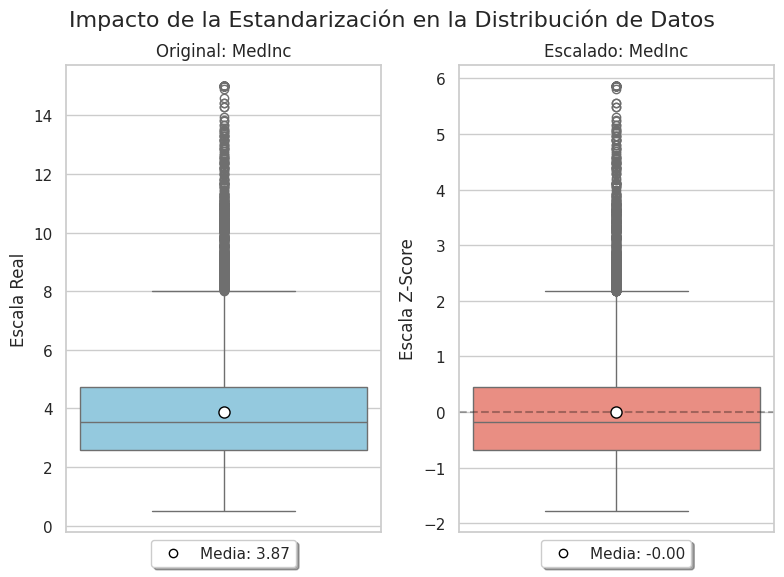

In [ ]:
df_escalado = pd.DataFrame(X_train_scaled, columns=X.columns)

sns.set(style="whitegrid")

# Calculo de las medias
media_orig = X.iloc[:, 0].mean()
media_esc = df_escalado.iloc[:, 0].mean()

fig, axs = plt.subplots(1, 2, figsize=(8, 6))

# 1. Boxplot - Original
sns.boxplot(y=X.iloc[:, 0], ax=axs[0], color="skyblue",
            showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
axs[0].set_title(f"Original: {X.columns[0]}")
axs[0].set_ylabel("Escala Real")

axs[0].plot([], [], 'o', color='white', markeredgecolor='black', label=f'Media: {media_orig:.2f}')
axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, 0), frameon=True, shadow=True)

# 2. Boxplot - Escalado
sns.boxplot(y=df_escalado.iloc[:, 0], ax=axs[1], color="salmon",
            showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
axs[1].set_title(f"Escalado: {X.columns[0]}")
axs[1].set_ylabel("Escala Z-Score")
axs[1].axhline(0, color='black', linestyle='--', alpha=0.3)

axs[1].plot([], [], 'o', color='white', markeredgecolor='black', label=f'Media: {media_esc:.2f}')
axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, 0), frameon=True, shadow=True)

plt.suptitle("Impacto de la Estandarización en la Distribución de Datos", fontsize=16, y=0.96)

plt.tight_layout()
plt.show()

El escalado mediante StandardScaler es una transformación lineal que ajusta los datos para que sean comparables entre sí sin alterar su esencia informativa.

Los efectos que se observan en la comparativa son:

* **Preservación de la Estructura Original:** A pesar de la transformación numérica, el escalado es una operación lineal que no altera la distribución de los datos. La morfología de la información (mediana, cuartiles y presencia de outliers) permanece idéntica. El proceso simplemente "traduce" las variables a un lenguaje común sin perder sus propiedades estadísticas intrínsecas.

* **Centrado de la Media (Efecto en la Optimización):** Al desplazar la media de cada variable a 0.00, se facilita el trabajo del algoritmo de Descenso de Gradiente, mantiendo los datos en el rango de mayor sensibilidad de las funciones de activación, evitando que las neuronas se "saturen" prematuramente.

* **Escalado de la Varianza (Unidad Estándar):** Al ajustar la dispersión para que la desviación estándar sea exactamente 1, se homogenizan todas las variables del dataset:
  * **Equidad de Pesos:** Elimina la ventaja artificial de las variables con rangos numéricos extensos. Sin esto, el modelo podría ignorar variables cruciales simplemente porque sus valores son pequeños.
  * **Interpretación Directa:** Tras el escalado, cada unidad representa una "desviación estándar". Un valor de +2.0 nos indica de inmediato que ese dato se encuentra significativamente por encima del promedio, independientemente de la variable original.

El escalado garantiza la estabilidad numérica y la rapidez de convergencia. Al operar en un punto optimo, la red neuronal logra un aprendizaje equilibrado, preciso y significativamente más veloz que si operara con magnitudes crudas y disparatadas.

---
### **Red Neuronal MLP para regresión**
---

El problema propuesto consiste en predecir una variable continua (`MedHouseVal`) a partir de variables tabulares, el tipo de red neuronal más apropiado es un Perceptrón Multicapa (MLP, Multi-Layer Perceptron).

---
**Ventajas de utilizar un MLP**

- Es el estándar para datos tabulares estructurados  
- Permite modelar relaciones no lineales entre variables  
- Puede capturar interacciones complejas que modelos lineales no detectan  

A diferencia de otros tipos de redes neuronales como las CNN o las RNN, el MLP no asume una estructura particular en los datos. Las Redes Convolucionales (CNN) están diseñadas para datos con estructura espacial (como imágenes), donde la cercanía entre variables es relevante y se buscan patrones locales. Por su parte, las Redes Recurrentes (RNN) se utilizan en datos secuenciales o temporales, donde el orden y la dependencia entre observaciones es fundamental. En este caso, al trabajar con datos tabulares donde cada variable es independiente y no existe un orden inherente ni relación espacial, el uso de un MLP resulta más adecuado.

---
**Estructura del modelo**

Un MLP está compuesto por:
- **Capa de entrada**: La capa de entrada es el punto donde los datos crudos ingresan a la red. Cada nodo de esta capa representa una característica o variable del conjunto de datos.
- **Capas ocultas**: Las capas ocultas son donde ocurre el aprendizaje profundo. Cada nodo en estas capas toma los valores de la capa anterior, los multiplica por pesos y los pasa a través de una función de activación, como ReLU (Rectified Linear Unit) o Sigmoid. Las salidas de las neuronas de la capa oculta se convierten en la entrada para la siguiente capa. Son estas capas las que permiten a los MLPs aprender relaciones no lineales en los datos.
- **Capa de salida**: La capa de salida proporciona el resultado final de la red, ya sea una clasificación o una regresión.


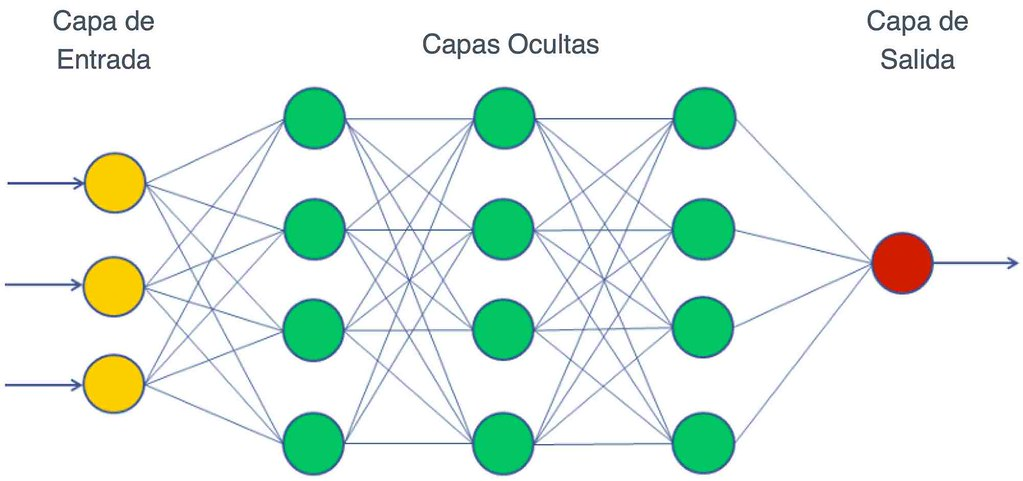

---
**Cálculos en una neurona**
Cada neurona en una capa toma las entradas de la capa anterior, las multiplica por pesos y agrega un sesgo (bias). Esta suma ponderada se transforma usando una función de activación, que introduce no linealidades en el modelo.La fórmula básica es:
$$
a = f\left(\sum w_i x_i + b\right)
$$
donde:
- \( w_i \) son los pesos  
- \( b \) es el sesgo  
- \( f \) es la función de activación  

---
**Función de activación**

Una vez que la neurona calcula el valor \( z \), este se transforma mediante una función de activación, que introduce no linealidad en el modelo.

Las funciones más comunes en MLP son:

- **ReLU (Rectified Linear Unit)**  
  Devuelve 0 si el valor es negativo, y el valor original si es positivo:

  $$
  f(z) = \max(0, z)
  $$

- **Sigmoide**  
  Convierte el valor en un número entre 0 y 1, útil principalmente en problemas de clasificación binaria:

  $$
  f(z) = \frac{1}{1 + e^{-z}}
  $$

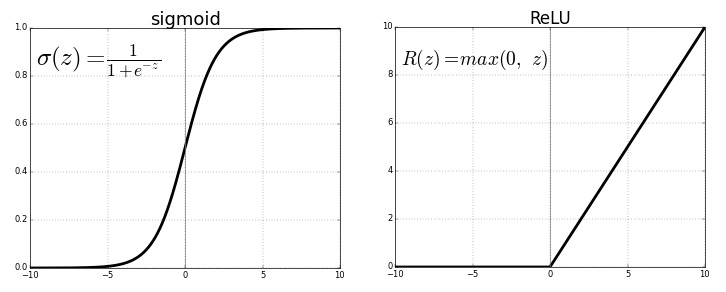

* **Tanh (Tangente hiperbólica)**

  La función Tanh es similar a la Sigmoide, pero escala los valores entre -1 y 1. Esto le permite centrarse en un rango más amplio de valores en lugar de restringirlos únicamente a positivos, lo que puede mejorar el rendimiento en ciertas tareas.

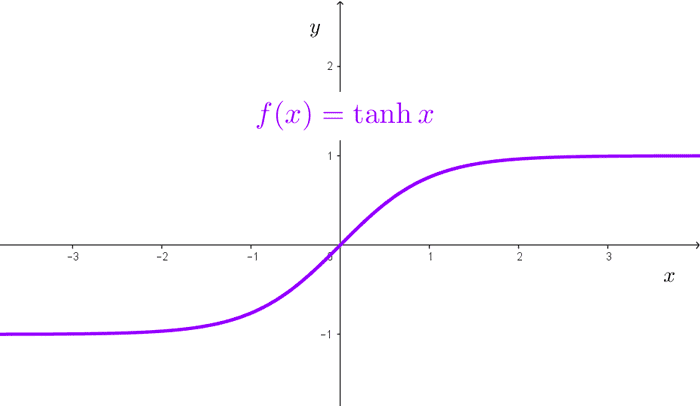

---


---
### Configuración y variantes del MLP

Para problemas de regresión, un MLP utiliza una única neurona de salida con activación lineal y se entrena minimizando el error cuadrático medio (MSE).

En cuanto a su complejidad, puede variar desde modelos simples con pocas capas (útiles como baseline), hasta arquitecturas más profundas con mayor capacidad de aprendizaje. A medida que aumenta la complejidad, se vuelve importante incorporar técnicas de regularización (como dropout o penalización L2) y ajustar hiperparámetros como el número de capas, neuronas y tasa de aprendizaje, con el objetivo de mejorar el desempeño sin caer en sobreajuste.



#### **Entrenamiento Inicial del modelo**

In [ ]:
# Modelo: MLP para regresión (scikit-learn)
# -----------------------------------------
# Definición del modelo

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    # Arquitectura de la red:
    # - 2 capas ocultas
    # - 64 neuronas en la primera, 32 en la segunda

    activation='relu',
    # Función de activación:
    # - Evita problemas de saturación (como sigmoid) VER

    solver='adam',
    # Optimizador:
    # - Adam combina momentum + adaptive learning rate
    # - Ideal para datasets medianos

    learning_rate_init=0.001,
    # Tasa de aprendizaje inicial:

    max_iter=300,
    # Número máximo de iteraciones:

    batch_size=32,
    # Tamaño de lote

    alpha=0.0001,
    # Regularización L2:
    # - Penaliza pesos grandes
    # - Reduce overfitting

    random_state=42,
    # Reproducibilidad

    early_stopping=True,
    # Detiene entrenamiento si no mejora en validación
    # Evita sobreajuste

    validation_fraction=0.1,
    # 10% del train se usa como validación interna

    n_iter_no_change=10
    # Número de iteraciones sin mejora antes de parar
)

# Entrenamiento
mlp.fit(X_train_scaled, y_train)

# Predicciones
y_pred = mlp.predict(X_test_scaled)

# Evaluación
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Resultados MLP:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Información adicional del entrenamiento
print("\nIteraciones realizadas:", mlp.n_iter_)
print("Loss final:", mlp.loss_)

Resultados MLP:
MSE: 0.3324
RMSE: 0.5765
R²: 0.7491

Iteraciones realizadas: 95
Loss final: 0.14863592014503774


El modelo de red neuronal obtuvo un R² de 0.75, lo que indica que logra explicar aproximadamente el 75% de la variabilidad en los precios de las propiedades.

El error promedio (RMSE) se sitúa en torno a 0.57, lo que representa un nivel de precisión razonable para un primer modelo sin ajuste fino de hiperparámetros.

Además, el entrenamiento se detuvo antes de alcanzar el máximo de iteraciones definido, lo que sugiere que el modelo convergió correctamente y que la estrategia de early stopping fue efectiva para evitar sobreajuste.

#### **Fine Tunning del modelo**

##### **Tamaño de la red**

In [ ]:
# Lista para recolectar los resultados
resultados_capas = []

# Incluyo también la configuración original (64, 32) para comparar
configuraciones = [
    (64, 32),  # modelo original
    (32,),
    (64,),
    (128, 64),
    (64, 32, 16)
]

for config in configuraciones:
    mlp = MLPRegressor(
        hidden_layer_sizes=config,
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=300,
        random_state=42,
        batch_size=32,
        validation_fraction=0.1,
        n_iter_no_change=10,
        early_stopping=True
    )

    mlp.fit(X_train_scaled, y_train)
    y_pred = mlp.predict(X_test_scaled)

    # Cálculo de métricas
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    # Guardo info
    resultados_capas.append({
        'Arquitectura': str(config),
        'R2': r2,
        'RMSE': rmse,
        'MSE': mse,
        'Iteraciones': mlp.n_iter_,
        'Loss Final': mlp.loss_
    })

# Creo el DataFrame
df_variantes_capas = pd.DataFrame(resultados_capas)

In [ ]:
styled_capas = df_variantes_capas.sort_values('R2', ascending=False).style \
    .set_caption("MLP - Comparativa de Arquitecturas de Capas<br><span style='font-size:16px; font-weight:normal; color:#666;'>Impacto de la profundidad y densidad neuronal en el rendimiento</span>") \
    .background_gradient(subset=['R2'], cmap='RdYlGn') \
    .background_gradient(subset=['RMSE', 'MSE'], cmap='RdYlGn_r') \
    .highlight_max(subset=['R2'], color='lightgreen') \
    .highlight_min(subset=['RMSE'], color='#4CAF50') \
    .format(precision=4) \
    .hide(axis="index") \
    .set_table_styles([
        {'selector': 'caption', 'props': [('color', '#2c3e50'), ('font-size', '18px'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding-bottom', '15px')]},
        {'selector': 'th', 'props': [('text-align', 'center'), ('padding', '10px'), ('background-color', '#f2f2f2')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])\
    .set_table_styles([
        # Estilo para el título
        {'selector': 'caption', 'props': [('color', '#2c3e50'),
                                          ('font-size', '18px'),
                                          ('font-weight', 'bold'),
                                          ('text-align', 'center'),
                                          ('padding-bottom', '15px'),
                                          ('line-height', '1.4')]},
        # Centrado de cabeceras
        {'selector': 'th', 'props': [('text-align', 'center'),
                                     ('padding', '12px'),
                                     ('background-color', '#f8f9fa')]},
        # Centrado de celdas
        {'selector': 'td', 'props': [('text-align', 'center'),
                                     ('padding', '10px')]}
    ])

# Mostrar en el Notebook
styled_capas

Arquitectura,R2,RMSE,MSE,Iteraciones,Loss Final
"(64, 32, 16)",0.7543,0.5705,0.3254,83,0.1392
"(64, 32)",0.7491,0.5765,0.3324,95,0.1486
"(128, 64)",0.7468,0.5792,0.3355,64,0.1461
"(64,)",0.7124,0.6173,0.3811,107,0.1903
"(32,)",0.7066,0.6235,0.3887,75,0.1945


In [ ]:
# Guardo df_variantes_capas en drive
df_variantes_capas.to_csv('df_variantes_capas.csv', index=False)

##### **Alphas / Learning Rate / Batch Size**

Una vez determinado una densidad y estructura de la red mas 'optima', se usa de base para iterar distintas alternativas del resto de los hiperparametros para lograr la combinacion mas optima.

In [ ]:
# ADVERTENCIA: Correr esta celda implica un tiempo de espera largo (15' usando aceleracion de GPU), se adjunta el dataset resultante para mayor simplicidad.

# Hiperparametros a Iterar

alphas = [0.00001, 0.0001, 0.001]
learning_rates = [0.0005, 0.001, 0.003]
batch_sizes = [16, 32, 64]

# Fijamos la arquitectura óptima encontrada
hidden_layer = (64, 32, 16)

# -----------------------------------------
# Iteración sobre combinaciones
# -----------------------------------------

results = []

for alpha, lr,bs in itertools.product(alphas, learning_rates, batch_sizes):

    mlp = MLPRegressor(
        hidden_layer_sizes=hidden_layer,
        activation='relu',
        solver='adam',
        learning_rate_init=lr,
        alpha=alpha,
        max_iter=500,
        batch_size=bs,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42
    )

    # Entrenamiento
    mlp.fit(X_train_scaled, y_train)

    # Predicción
    y_pred = mlp.predict(X_test_scaled)

    # Métricas
    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mse = mean_squared_error(y_test, y_pred)

    # Guardar resultados
    results.append({
        "alpha": alpha,
        "learning_rate": lr,
        "batch_size": bs,
        "R2": r2,
        "RMSE": rmse,
        "MSE": mse,
        "iterations": mlp.n_iter_,
        "Loss Final": mlp.loss_
    })

# -----------------------------------------
# Resultados
# -----------------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2", ascending=False)

# -----------------------------------------
# Genero el .csv
# -----------------------------------------
results_df.to_csv('results_df.csv', index=False)

In [ ]:
styled_df = results_df.sort_values('R2', ascending=False).style \
    .set_caption("MLP - Comparativa de Rendimiento<br><span style='font-size:16px; color:#666;'>Densidad de la Red Neuronal 64,32,16</span>") \
    .background_gradient(subset=['R2'], cmap='RdYlGn') \
    .background_gradient(subset=['RMSE', 'MSE'], cmap='RdYlGn_r') \
    .format(precision=5) \
    .hide(axis="index") \
    .set_table_styles([
        {'selector': 'caption', 'props': [('color', '#2c3e50'), ('font-size', '18px'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding-bottom', '15px')]},
        {'selector': 'th', 'props': [('text-align', 'center'), ('padding', '10px'), ('background-color', '#f2f2f2')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])\
    .set_table_styles([
        {'selector': 'caption', 'props': [('color', '#2c3e50'),
                                          ('font-size', '18px'),
                                          ('font-weight', 'bold'),
                                          ('text-align', 'center'),
                                          ('padding-bottom', '15px'),
                                          ('line-height', '1.4')]},
        {'selector': 'th', 'props': [('text-align', 'center'),
                                     ('padding', '10px')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])

styled_df

alpha,learning_rate,batch_size,R2,RMSE,MSE,iterations,Loss Final
0.00100,0.00300,64,0.77763,0.54276,0.29459,107,0.12766
0.00010,0.00300,16,0.77226,0.54927,0.30170,73,0.14367
0.00100,0.00300,16,0.77009,0.55189,0.30458,76,0.15517
0.00001,0.00300,32,0.76794,0.55446,0.30743,72,0.13628
0.00010,0.00100,16,0.76721,0.55533,0.30839,96,0.13160
0.00100,0.00100,16,0.76407,0.55906,0.31255,60,0.14935
0.00010,0.00050,16,0.76372,0.55948,0.31301,135,0.13140
0.00001,0.00300,16,0.76015,0.56369,0.31774,56,0.14388
0.00100,0.00300,32,0.75876,0.56532,0.31959,56,0.15328
0.00010,0.00100,32,0.75434,0.57048,0.32544,83,0.13919


In [ ]:
initial_performance = df_variantes_capas.iloc[0][['R2', 'RMSE', 'MSE']]
fine_tuned_performance = results_df.iloc[0][['R2', 'RMSE', 'MSE']]

# Creo el DF para comparacion
gcia_fine_tunning = pd.DataFrame({
    'Rendimiento': ['MLP - Inicial', 'MLP - Fine Tunning'],
    'R2': [initial_performance['R2'], fine_tuned_performance['R2']],
    'RMSE': [initial_performance['RMSE'], fine_tuned_performance['RMSE']],
    'MSE': [initial_performance['MSE'], fine_tuned_performance['MSE']]
})

# Calculo las variaciones
variation_row = {
    'Rendimiento': 'MLP - Variacion (%)',
    'R2': (fine_tuned_performance['R2'] - initial_performance['R2'])/initial_performance['R2']*100,
    'RMSE': (initial_performance['RMSE'] - fine_tuned_performance['RMSE'])/initial_performance['R2']*100,
    'MSE': (initial_performance['MSE'] - fine_tuned_performance['MSE'])/initial_performance['R2']*100
}

# Append the variation row
gcia_fine_tunning = pd.concat([gcia_fine_tunning, pd.DataFrame([variation_row])], ignore_index=True)


In [ ]:
styled_gcia_fine_tunning = gcia_fine_tunning.style \
    .set_caption("MLP - Comparación de Rendimiento (Inicial vs. Fine-Tuning)<br><span style='font-size:16px; font-weight:normal; color:#666;'>Impacto del ajuste de hiperparámetros en las métricas del modelo</span>") \
    .format(precision=4) \
    .hide(axis="index") \
    .apply(lambda x: ['background-color: lightgreen' if x['Rendimiento'] == 'MLP - Variacion (%)' else '' for _ in x], axis=1) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('color', '#2c3e50'), ('font-size', '18px'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding-bottom', '15px')]},
        {'selector': 'th', 'props': [('text-align', 'center'), ('padding', '10px'), ('background-color', '#f2f2f2')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])\
    .set_table_styles([
        {'selector': 'caption', 'props': [('color', '#2c3e50'),
                                          ('font-size', '18px'),
                                          ('font-weight', 'bold'),
                                          ('text-align', 'center'),
                                          ('padding-bottom', '15px'),
                                          ('line-height', '1.4')]},
        {'selector': 'th', 'props': [('text-align', 'center'),
                                     ('padding', '10px')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])

styled_gcia_fine_tunning

Rendimiento,R2,RMSE,MSE
MLP - Inicial,0.7491,0.5765,0.3324
MLP - Fine Tunning,0.7776,0.5428,0.2946
MLP - Variacion (%),3.8084,4.5076,5.0452


In [ ]:
# -----------------------------------------
# Genero el .csv
# -----------------------------------------
gcia_fine_tunning.to_csv('gcia_fine_tunning.csv', index=False)

###### **Conclusiones** EXPLICAR MEJOR



#### **Re-entrenamiento con parámetros óptimos**

In [ ]:
best_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.003,
    alpha=0.001,
    batch_size=64,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

best_mlp.fit(X_train_scaled, y_train)

y_pred = best_mlp.predict(X_test_scaled)

r2_mlp = r2_score(y_test, y_pred)
mse_mlp = mean_squared_error(y_test, y_pred)
rmse_mlp = np.sqrt(mse_mlp)

#### **Graficas y análisis**

##### **Curva de pérdida**

La función de pérdida es la métrica que mide la "equivocación" del modelo. Representa la diferencia entre el valor real y la predicción realizada por la red neuronal.

* **Objetivo:** El entrenamiento consiste en minimizar este valor. Cuanto más bajo es el Loss, mejores son las predicciones del modelo.
* **Aprendizaje:** El optimizador utiliza el gradiente de esta pérdida para ajustar los pesos del MLP en cada iteración.

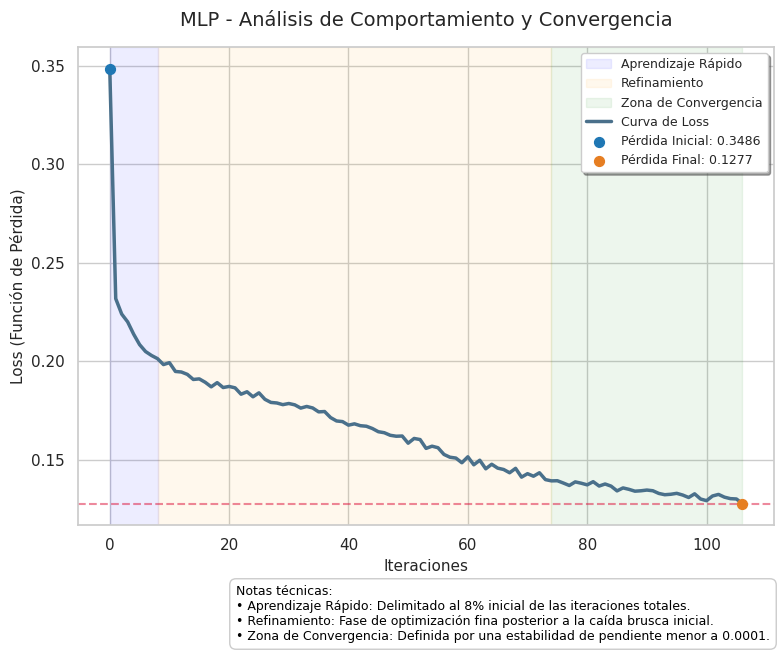

In [ ]:
sns.set(style="whitegrid")
loss = best_mlp.loss_curve_
n_iter = len(loss)

# --- PARÁMETROS DE DELIMITACIÓN ---
pct_aprendizaje = 0.08      # 8% para la fase inicial
umbral_conv = 0.0001        # Umbral de convergencia

# --- CÁLCULO DE ÍNDICES DE LAS AREAS ---
idx_aprendizaje_rapido = int(n_iter * pct_aprendizaje)
diffs = np.abs(np.diff(loss))

try:
    indices_estables = np.where(diffs < umbral_conv)[0]
    idx_convergencia = indices_estables[indices_estables > idx_aprendizaje_rapido][0]
except IndexError:
    idx_convergencia = int(n_iter * 0.85)

# --- GRÁFICO ---
plt.figure(figsize=(8, 6))

# Sombreados
plt.axvspan(0, idx_aprendizaje_rapido, color='blue', alpha=0.07, label="Aprendizaje Rápido")
plt.axvspan(idx_aprendizaje_rapido, idx_convergencia, color='orange', alpha=0.07, label="Refinamiento")
plt.axvspan(idx_convergencia, n_iter - 1, color='green', alpha=0.07, label="Zona de Convergencia")

# Curva de Loss
plt.plot(loss, linewidth=2.5, color='#4A708B', label="Curva de Loss", zorder=4)

# --- PUNTOS DE EXTREMO CON VALORES EN LEYENDA ---
# Punto Inicial
plt.scatter(0, loss[0], color='#1f77b4', s=50, zorder=5,
            label=f"Pérdida Inicial: {loss[0]:.4f}")

# Punto Final
plt.scatter(n_iter-1, loss[-1], color='#e67e22', s=50, zorder=5,
            label=f"Pérdida Final: {loss[-1]:.4f}")

# Línea horizontal de referencia
plt.axhline(loss[-1], linestyle="--", color="crimson", alpha=0.5, linewidth=1.5, zorder=2)

# Títulos y Leyenda
plt.title("MLP - Análisis de Comportamiento y Convergencia", fontsize=14, pad=15)
plt.xlabel("Iteraciones", fontsize=11)
plt.ylabel("Loss (Función de Pérdida)", fontsize=11)

# Leyenda
plt.legend(loc='upper right', frameon=True, shadow=True, facecolor='white', fontsize=9)

# --- NOTAS AL PIE ---
notas = (
    f"Notas técnicas:\n"
    f"• Aprendizaje Rápido: Delimitado al {pct_aprendizaje*100:.0f}% inicial de las iteraciones totales.\n"
    f"• Refinamiento: Fase de optimización fina posterior a la caída brusca inicial.\n"
    f"• Zona de Convergencia: Definida por una estabilidad de pendiente menor a {umbral_conv}."
)

plt.figtext(0.305, -0.08, notas, fontsize=9, color='black',
            ha='left', bbox=dict(facecolor='none', edgecolor='#CCCCCC', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

La gráfica confirma un entrenamiento óptimo y estable.

1. **Eficiencia de Aprendizaje:** El modelo logra reducir el **63% del error** total en apenas el 8% de las iteraciones iniciales, lo que valida que el *learning rate* (0.003) es ideal para capturar la estructura de los datos rápidamente.
2. **Estabilidad:** La transición suave hacia la zona de refinamiento indica que el modelo no presenta oscilaciones ni divergencias.
3. **Criterio de Parada:** El entrenamiento finaliza correctamente mediante el mecanismo de early stopping, el cual detiene el proceso de manera automática cuando la ganancia en la precisión se vuelve marginal (menor a 0.0001 en este caso), esta estrategia no solo garantiza el mejor compromiso entre el rendimiento predictivo y el costo computacional sino que actúa como una salvaguarda para evitar el overfitting, impidiendo que el modelo memorice el ruido de los datos de entrenamiento y pierda su capacidad de generalización.


##### **Predicción vs Valor Real**

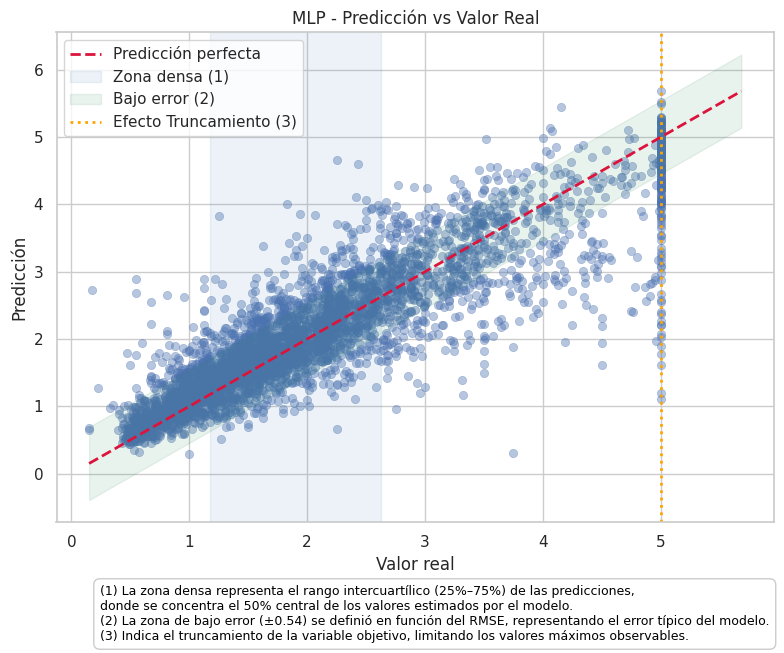

In [ ]:
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
q1 = np.percentile(y_test, 25)
q3 = np.percentile(y_test, 75)

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

# Scatter
sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.4,
    edgecolor=None
)

# Línea ideal (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color = "crimson",
    linewidth=2,
    label="Predicción perfecta"
)

# Zona densa
plt.axvspan(
    q1, q3,
    color="steelblue",
    alpha=0.1,
    label="Zona densa (1)"
)

# Zona de bajo error (±RMSE alrededor de la diagonal)
x_vals = np.linspace(min_val, max_val, 100)

plt.fill_between(
    x_vals,
    x_vals - rmse,
    x_vals + rmse,
    color="seagreen",
    alpha=0.1,
    label="Bajo error (2)"
)

# Línea de truncamiento (y = 5)
plt.axvline(
    5,
    linestyle=":",
    linewidth=2,
    color = "orange",
    label="Efecto Truncamiento (3)"
)

# Labels
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("MLP - Predicción vs Valor Real")

# --- NOTAS AL PIE ---
notas = (
    f"(1) La zona densa representa el rango intercuartílico (25%–75%) de las predicciones,\ndonde se concentra el 50% central de los valores estimados por el modelo.\n"
    f"(2) La zona de bajo error (±{rmse:.2f}) se definió en función del RMSE, representando el error típico del modelo.\n"
    f"(3) Indica el truncamiento de la variable objetivo, limitando los valores máximos observables."
)

plt.figtext(0.135, -0.08, notas, fontsize=9, color='black',
            ha='left', bbox=dict(facecolor='none', edgecolor='#CCCCCC', boxstyle='round,pad=0.5'))



plt.legend()
plt.tight_layout()


El gráfico muestra que el modelo logra capturar adecuadamente la tendencia general de los datos, con una distribución de puntos cercana a la diagonal ideal.

Sin embargo, se observa una mayor dispersión en valores altos, lo que indica una menor precisión en la predicción de propiedades de mayor valor.

Además, se identifica una concentración de observaciones en el valor máximo, lo cual sugiere un efecto de truncamiento en la variable objetivo. Esto limita la capacidad del modelo para aprender correctamente en ese rango.

##### **Distribución de errores**

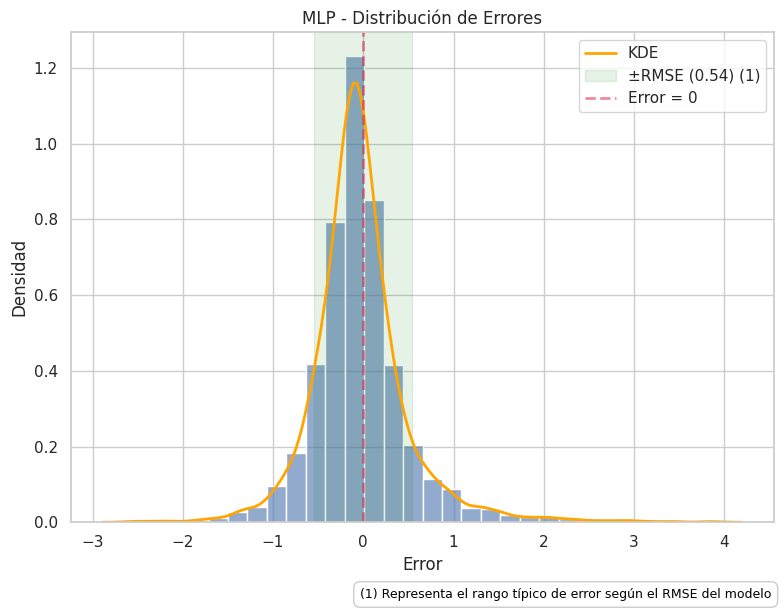

In [ ]:
sns.set(style="whitegrid")

residuos = y_test - y_pred

plt.figure(figsize=(8,6))

# Histograma
sns.histplot(
    residuos,
    bins=30,
    stat="density",   # importante si superponés KDE
    alpha=0.6
)

# KDE separado
sns.kdeplot(
    residuos,
    color="orange",
    linewidth=2,
    label="KDE"
)
rmse = np.sqrt(np.mean((residuos)**2))

# Area de bajo error
plt.axvspan(
    -rmse,
    rmse,
    color="green",
    alpha=0.1,
    label=f"±RMSE ({rmse:.2f}) (1)"
)

# Línea en 0
plt.axvline(0, linestyle="--", linewidth=2, color = "crimson", alpha=0.5, label="Error = 0")

plt.title("MLP - Distribución de Errores")
plt.xlabel("Error")
plt.ylabel("Densidad")

# --- NOTAS AL PIE ---
notas = (
    f"(1) Representa el rango típico de error según el RMSE del modelo"
)

plt.figtext(0.46, -0.01, notas, fontsize=9, color='black',
            ha='left', bbox=dict(facecolor='none', edgecolor='#CCCCCC', boxstyle='round,pad=0.5'))

plt.legend()
plt.tight_layout()
plt.show()

La distribución de los errores se encuentra insesgada, con su pico máximo relativamente centrados en cero, lo que confirma la ausencia de errores sistemáticos en las predicciones. La morfología de la distribución se aproxima a una campana de Gauss, indicando que los residuos son aleatorios y que el modelo captura correctamente la tendencia central de los datos.

La concentración de la densidad dentro de la franja sombreada ($\pm RMSE$) demuestra una alta precisión, aunque se observa una leve asimetría positiva (cola derecha más larga) lo cual es consistente con una menor precisión en ciertos casos particulares, especialmente en valores más altos de la variable objetivo, debido al truncamiento de la misma ya mencionado previamente.

##### **Error vs Predicción**

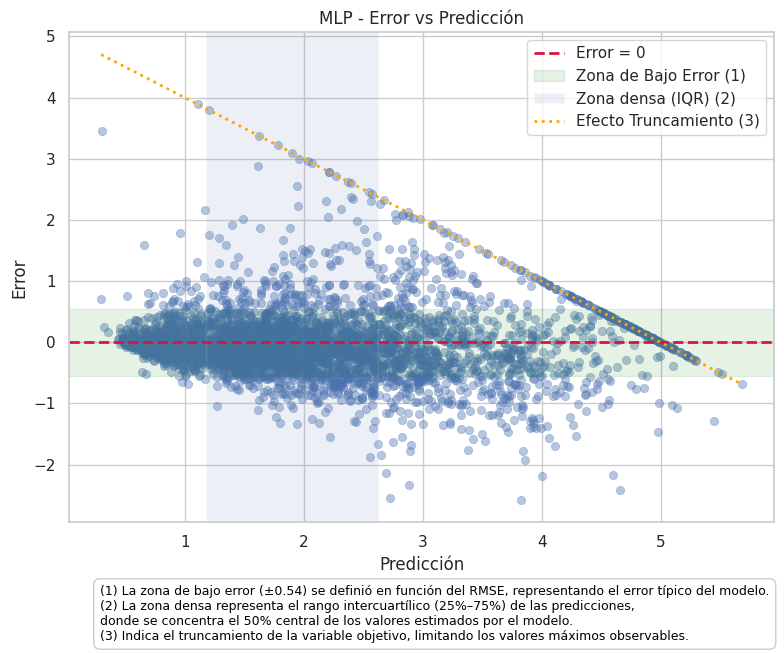

In [ ]:
sns.set(style="whitegrid")

residuos = y_test - y_pred

plt.figure(figsize=(8,6))

# Scatter
sns.scatterplot(
    x=y_pred,
    y=residuos,
    alpha=0.4,
    edgecolor=None
)

# Línea horizontal en error = 0
plt.axhline(
    0,
    linestyle="--",
    linewidth=2,
    label="Error = 0",
    color = "crimson"
)

# Bajo Error
plt.axhspan(
    -rmse, rmse,
    alpha=0.1,
    color = "green",
    label="Zona de Bajo Error (1)"
)

# Zona densa
plt.axvspan(q1, q3,
    alpha=0.1,
    label="Zona densa (IQR) (2)")

# Línea teórica del truncamiento
x_vals = np.linspace(y_pred.min(), y_pred.max(), 100)
y_vals = 5 - x_vals

plt.plot(
    x_vals,
    y_vals,
    linestyle=":",
    linewidth=2,
    color = "orange",
    label="Efecto Truncamiento (3)"
)

# --- NOTAS AL PIE ---
notas = (
    f"(1) La zona de bajo error (±{rmse:.2f}) se definió en función del RMSE, representando el error típico del modelo.\n"
    f"(2) La zona densa representa el rango intercuartílico (25%–75%) de las predicciones,\ndonde se concentra el 50% central de los valores estimados por el modelo.\n"
    f"(3) Indica el truncamiento de la variable objetivo, limitando los valores máximos observables."
)

plt.figtext(0.135, -0.08, notas, fontsize=9, color='black',
            ha='left', bbox=dict(facecolor='none', edgecolor='#CCCCCC', boxstyle='round,pad=0.5'))

# Labels
plt.xlabel("Predicción")
plt.ylabel("Error")
plt.title("MLP - Error vs Predicción")

plt.legend()
plt.tight_layout()
plt.show()

El gráfico muestra que el modelo presenta un buen comportamiento general, con errores distribuidos alrededor de cero, lo que indica ausencia de sesgo sistemático en las predicciones.

Se observa una mayor concentración de predicciones en el rango medio de la grafica que es coincidente con la mayor densidad de datos en el dataset. En este rango, el modelo presenta mejor desempeño, con errores más acotados.

A medida que aumentan las predicciones, la dispersión del error también crece, lo que evidencia una menor precisión en valores altos. Esto se debe tanto a la menor cantidad de observaciones en ese rango como a la presencia de un límite superior en la variable objetivo.

Se identifica una acumulacion de forma diagonal en la parte superior del gráfico. Este patrón se explica por el truncamiento de la variable objetivo, cuyo valor máximo es 5.

##### Residuos vs Valor Real

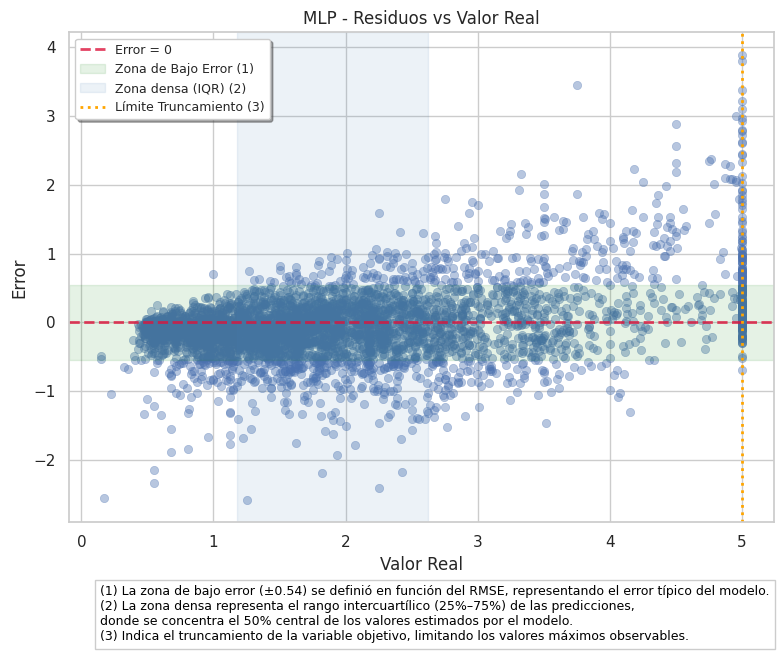

In [ ]:
sns.set(style="whitegrid")

residuos_mlp = y_test - y_pred # Usando los residuos del MLP
rmse_mlp = np.sqrt(np.mean(residuos_mlp**2))

plt.figure(figsize=(8,6))

# Scatter: Real vs Residuos (MLP)
sns.scatterplot(
    x=y_test,
    y=residuos_mlp,
    alpha=0.4,
    edgecolor=None
)

# Línea en error = 0
plt.axhline(
    0,
    linestyle="--",
    linewidth=2,
    color="crimson",
    alpha=0.8,
    label="Error = 0"
)

# Zona de bajo error (±RMSE) (1)
plt.axhspan(
    -rmse_mlp,
    rmse_mlp,
    color="green",
    alpha=0.1,
    label=f"Zona de Bajo Error (1)"
)

# Zona densa (IQR sobre valores REALES) (2)
q1_test = np.percentile(y_test, 25)
q3_test = np.percentile(y_test, 75)

plt.axvspan(
    q1_test,
    q3_test,
    color="steelblue",
    alpha=0.1,
    label="Zona densa (IQR) (2)"
)

# Línea de truncamiento (Vertical) (3)
plt.axvline(
    5,
    linestyle=":",
    linewidth=2,
    color="orange",
    label="Límite Truncamiento (3)"
)

# Labels
plt.xlabel("Valor Real")
plt.ylabel("Error")
plt.title("MLP - Residuos vs Valor Real")

# Leyenda
plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=9)
plt.tight_layout()

# --- NOTAS AL PIE ---
notas_pie_mlp = (
    f"(1) La zona de bajo error (±{rmse:.2f}) se definió en función del RMSE, representando el error típico del modelo.\n"
    f"(2) La zona densa representa el rango intercuartílico (25%–75%) de las predicciones,\ndonde se concentra el 50% central de los valores estimados por el modelo.\n"
    f"(3) Indica el truncamiento de la variable objetivo, limitando los valores máximos observables."
)

plt.figtext(0.135, -0.08, notas_pie_mlp, fontsize=9, color='black',
            ha='left', bbox=dict(facecolor='none', edgecolor='#CCCCCC'))

plt.show()

El modelo logra mantener una dispersión uniforme. Esto indica que las capas ocultas han capturado patrones no lineales que estabilizan la predicción, incluso cuando el valor de la propiedad aumenta.

#### **MLP - Conclusión general del modelo**

El modelo de red neuronal (MLP) demuestra un desempeño sólido en la predicción del valor medio de las viviendas logrando capturar adecuadamente la relación entre las variables predictoras y la variable objetivo. El análisis gráfico confirma una buena capacidad de generalización, especialmente en el rango intercuartílico (Zona Densa), donde el modelo muestra su mayor precisión y consistencia.

El proceso de entrenamiento fue estable, con una convergencia clara de la función de pérdida y una transición fluida entre las etapas de aprendizaje rápido y refinamiento, esto, sumado a una distribución de residuos centrada en cero y con una distribucion cercana a la normal ratifica que el modelo es insesgado en su tendencia central y que los hiperparámetros (como el learning rate y el early stopping) fueron seleccionados adecuadamente para evitar el sobreentrenamiento.

Sin embargo se observan limitaciones en el extremo de la distribución:

* **Efecto de Truncamiento:** Las gráficas de "Predicción vs. Real" y "Error vs. Predicción" revelan un sesgo inducido por el límite superior de los datos (valor fijado en 5.0). Esto genera una correlación lineal negativa entre el error y la predicción en el extremo alto (el modelo tiende a subestimar sistemáticamente las propiedades de lujo debido a la frontera artificial en los datos de entrenamiento).

* **Dispersión en Outliers en Rangos Altos:** La mayor dispersión del error en valores altos sugiere la posible existencia de variables latentes (características de viviendas costosas) que el modelo no logra capturar totalmente con la arquitectura actual o debido a la menor densidad de muestras en ese segmento.

El modelo se presenta confiable para valoraciones de mercado masivo (rango medio), pero debe ser utilizado con cautela o complementado con modelos específicos para el segmento de propiedades de alto valor.

---
### **Regresión Lineal**
---

La regresión lineal modela la relación entre una variable objetivo y un conjunto de variables predictoras mediante una combinación lineal:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n
$$

El objetivo es encontrar los coeficientes $(\beta)$ que minimicen el error entre los valores reales y los predichos, típicamente a través del Error Cuadrático Medio:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Este modelo asume una relación lineal entre las variables, lo que limita su capacidad para capturar patrones más complejos.

#### **Entrenamiento del modelo**

In [ ]:
# Inicialización del modelo
lr = LinearRegression()

# Entrenamiento
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Resultados Regresión Lineal:")
print(f"MSE: {mse_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²: {r2_lr:.4f}")

Resultados Regresión Lineal:
MSE: 0.5235
RMSE: 0.7236
R²: 0.6048


#### **Graficas y análisis**

El modelo de regresión lineal presenta un desempeño inferior en comparación con la red neuronal, con un $R^2\approx 0.6$, lo que indica que logra explicar una proporción moderada de la variabilidad en los datos.

El valor de error obtenido $RMSE \approx 0.72 $ es significativamente mayor al observado en el modelo MLP, evidenciando una menor precisión en las predicciones.

Estos resultados sugieren que la relación entre las variables predictoras y la variable objetivo no es puramente lineal, y que un modelo más flexible, como una red neuronal, resulta más adecuado para capturar patrones complejos presentes en el dataset.


In [ ]:
comp_modelos = pd.DataFrame({
    'modelo': ['MLP', 'Regresion Lineal'],
    'R2': [r2_mlp, r2_lr],
    'RMSE': [rmse_mlp, rmse_lr],
    'MSE': [mse_mlp, mse_lr]
})

variation_r2 = ((r2_mlp - r2_lr) / r2_mlp) * 100
variation_rmse = ((rmse_mlp - rmse_lr) / rmse_mlp) * 100
variation_mse = ((mse_mlp - mse_lr) / mse_mlp) * 100

registro_variacion = {
    'modelo': 'Variacion (%)',
    'R2': variation_r2,
    'RMSE': variation_rmse,
    'MSE': variation_mse
}

comp_modelos = pd.concat([comp_modelos, pd.DataFrame([registro_variacion])], ignore_index=True)


In [ ]:
styled_comp_modelos = comp_modelos.style \
    .set_caption("Comparación de Rendimiento (MLP vs. Regresión Lineal)<br><span style='font-size:16px; font-weight:normal; color:#666;'>(Calculo Variación: Base MLP))</span>") \
    .format(precision=4) \
    .hide(axis="index") \
    .apply(lambda x: ['background-color: lightgreen' if x['modelo'] == 'Variacion (%)' else '' for _ in x], axis=1) \
    .set_table_styles([
        {'selector': 'caption', 'props': [('color', '#2c3e50'), ('font-size', '18px'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding-bottom', '15px')]},
        {'selector': 'th', 'props': [('text-align', 'center'), ('padding', '10px'), ('background-color', '#f2f2f2')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])\
    .set_table_styles([
        {'selector': 'caption', 'props': [('color', '#2c3e50'),
                                          ('font-size', '18px'),
                                          ('font-weight', 'bold'),
                                          ('text-align', 'center'),
                                          ('padding-bottom', '15px'),
                                          ('line-height', '1.4')]},
        {'selector': 'th', 'props': [('text-align', 'center'),
                                     ('padding', '10px')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])

styled_comp_modelos

modelo,R2,RMSE,MSE
MLP,0.7776,0.5428,0.2946
Regresion Lineal,0.6048,0.7236,0.5235
Variacion (%),22.2240,-33.3107,-77.7174


##### **Predicción vs Valor Real**

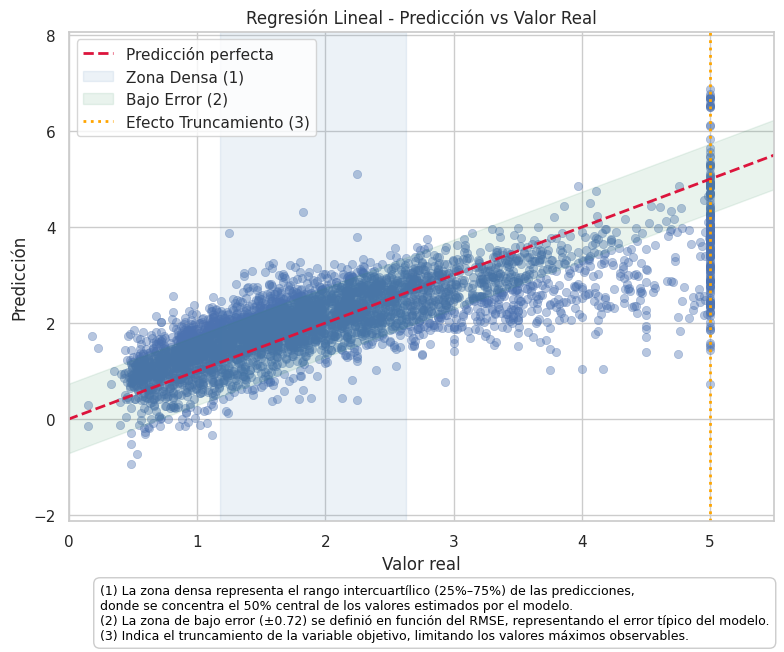

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

# Scatter
sns.scatterplot(
    x=y_test,
    y=y_pred_lr,
    alpha=0.4,
    edgecolor=None
)

# Línea ideal (y = x)
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color = "crimson",
    linewidth=2,
    label="Predicción perfecta"
)

# --- Zona densa (IQR sobre valores reales) ---
q1 = np.percentile(y_test, 25)
q3 = np.percentile(y_test, 75)

plt.axvspan(
    q1, q3,
    color="steelblue",
    alpha=0.1,
    label="Zona Densa (1)"
)

# --- Zona de bajo error (±RMSE alrededor de la diagonal) ---
rmse_lr = np.sqrt(np.mean((y_test - y_pred_lr)**2))

x_vals = np.linspace(min_val, max_val, 100)

plt.fill_between(
    x_vals,
    x_vals - rmse_lr,
    x_vals + rmse_lr,
    color="seagreen",
    alpha=0.1,
    label="Bajo Error (2)"
)

# --- Línea de truncamiento ---
plt.axvline(
    5,
    linestyle=":",
    linewidth=2,
    color = "orange",
    label="Efecto Truncamiento (3)"
)

# Labels
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Regresión Lineal - Predicción vs Valor Real")

plt.legend()
plt.tight_layout()

'''
# --- Notas al pie ---
plt.figtext(1, -0.02, "(1) La zona densa representa el rango intercuartílico (25%–75%) de las predicciones,\ndonde se concentra el 50% central de los valores estimados por el modelo.", ha="right", fontsize=9)
plt.figtext(1, -0.05, f"(2) La zona de bajo error (±{rmse:.2f}) se definió en función del RMSE, representando el error típico del modelo.", ha="right", fontsize=9)
plt.figtext(1, -0.08, "(3) Indica el truncamiento de la variable objetivo, limitando los valores máximos observables.",ha="right",fontsize=9)
'''
# --- NOTAS AL PIE ---
notas = (
    f"(1) La zona densa representa el rango intercuartílico (25%–75%) de las predicciones,\ndonde se concentra el 50% central de los valores estimados por el modelo.\n"
    f"(2) La zona de bajo error (±{rmse_lr:.2f}) se definió en función del RMSE, representando el error típico del modelo.\n"
    f"(3) Indica el truncamiento de la variable objetivo, limitando los valores máximos observables."
)

plt.figtext(0.135, -0.08, notas, fontsize=9, color='black',
            ha='left', bbox=dict(facecolor='none', edgecolor='#CCCCCC', boxstyle='round,pad=0.5'))

plt.xlim(0, 5.5)

plt.show()

El gráfico refleja un modelo con una capacidad de ajuste limitada frente a la complejidad de los datos, destacando los siguientes puntos:

A diferencia del MLP, la Regresión Lineal no puede "curvarse" para seguir la tendencia de los datos. Esto queda exteriorizado en una mayor dispersión por  fuera de la zona de bajo error 0.

Mientras que el MLP lograba aproximarse mejor a los valores altos, la Regresión Lineal muestra una "nube" mucho más errática en el límite superior. Esto confirma que la relación entre los predictores y el precio de la vivienda tiene componentes no lineales que un modelo de línea recta simplemente no puede capturar.

El rango de bajo error ($\pm 0.72$) es significativamente más ancho que el del MLP ($\pm 0.54$). Esto indica que, incluso en el rango medio de los datos (zona densa), las predicciones lineales son menos fiables y presentan una varianza mayor.

##### **Distribucion de errores**

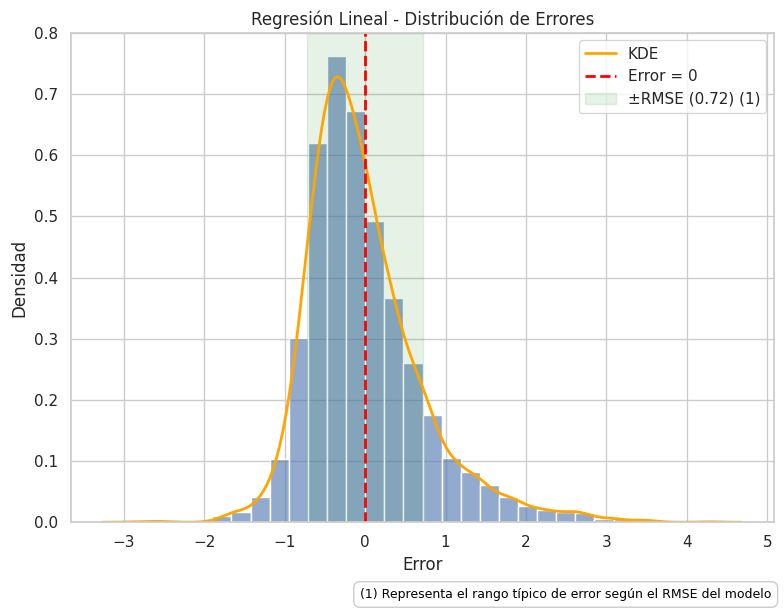

In [ ]:
sns.set(style="whitegrid")

residuos_lr = y_test - y_pred_lr

plt.figure(figsize=(8,6))

# Histograma
sns.histplot(
    residuos_lr,
    bins=30,
    stat="density",
    alpha=0.6
)

# KDE
sns.kdeplot(
    residuos_lr,
    color="orange",
    linewidth=2,
    label="KDE"
)

# Línea en error = 0
plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    color="red",
    label="Error = 0"
)

# RMSE como zona sombreada
rmse_lr = np.sqrt(np.mean((residuos_lr)**2))

plt.axvspan(
    -rmse_lr,
    rmse_lr,
    color="green",
    alpha=0.1,
    label=f"±RMSE ({rmse_lr:.2f}) (1)"
)

# Labels
plt.title("Regresión Lineal - Distribución de Errores")
plt.xlabel("Error")
plt.ylabel("Densidad")

plt.legend()
plt.tight_layout()

# --- NOTAS AL PIE ---
notas = (
    f"(1) Representa el rango típico de error según el RMSE del modelo"
)

plt.figtext(0.46, -0.01, notas, fontsize=9, color='black',
            ha='left', bbox=dict(facecolor='none', edgecolor='#CCCCCC', boxstyle='round,pad=0.5'))

plt.show()

El gráfico de residuos de la Regresión Lineal revela un desempeño menos equilibrado que el modelo de red neuronal MLP.

A diferencia del MLP, la distribución no es tan simétrica. El desplazamiento del pico (moda) hacia la izquierda del cero indica un sesgo sistemático, el modelo tiene una tendencia más marcada a sobreestimar o subestimar ciertos rangos de manera no compensada.

La cola hacia la derecha (errores positivos altos) es notablemente más larga y gruesa. Esto confirma que la Regresión Lineal tiene dificultades importantes para predecir valores altos, generando errores de gran magnitud que el modelo no logra mitigar debido a su rigidez matemática.

La franja verde de bajo error es más ancha ($0.72$ vs $0.54$ del MLP). Esto significa que la "incertidumbre" típica de una predicción lineal es casi un 33% mayor que la de la red neuronal, lo que se traduce en pronósticos menos confiables en todo el espectro de datos.

##### **Error vs Predicción**

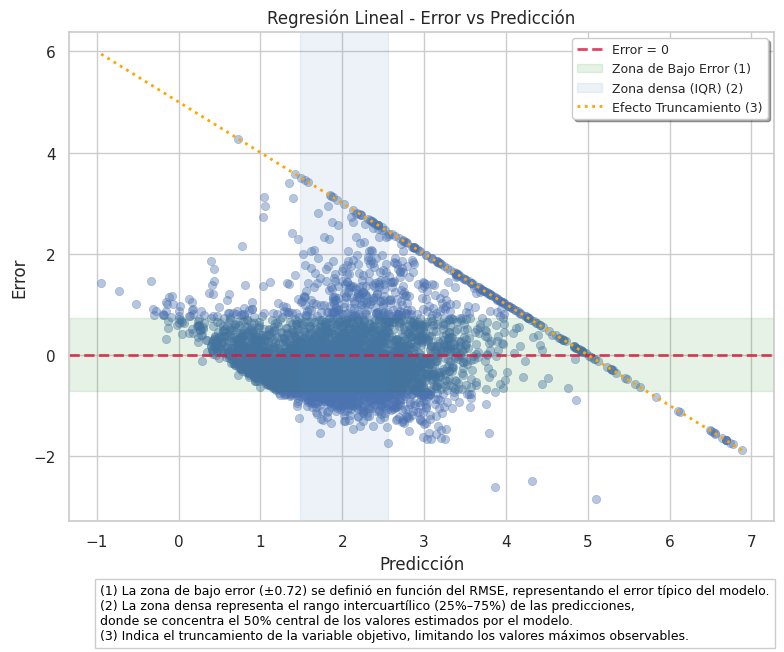

In [ ]:
sns.set(style="whitegrid")

residuos_lr = y_test - y_pred_lr
rmse_lr = np.sqrt(np.mean(residuos_lr**2))

plt.figure(figsize=(8,6))

# Scatter
sns.scatterplot(
    x=y_pred_lr,
    y=residuos_lr,
    alpha=0.4,
    edgecolor=None
)

# Línea en error = 0
plt.axhline(
    0,
    linestyle="--",
    linewidth=2,
    color="crimson", # Cambiado a crimson para mantener tu estilo previo
    alpha=0.8,
    label="Error = 0"
)

# Zona de bajo error (±RMSE) - AGREGADO (1)
plt.axhspan(
    -rmse_lr,
    rmse_lr,
    color="green",
    alpha=0.1,
    label=f"Zona de Bajo Error (1)"
)

# Zona densa (IQR sobre predicciones) - AGREGADO (2)
q1 = np.percentile(y_pred_lr, 25)
q3 = np.percentile(y_pred_lr, 75)

plt.axvspan(
    q1,
    q3,
    color="steelblue",
    alpha=0.1,
    label="Zona densa (IQR) (2)"
)

# Línea de truncamiento teórica - AGREGADO (3)
x_vals = np.linspace(y_pred_lr.min(), y_pred_lr.max(), 100)
y_vals = 5 - x_vals

plt.plot(
    x_vals,
    y_vals,
    linestyle=":",
    linewidth=2,
    color="orange", # Color consistente con tus gráficos anteriores
    label="Efecto Truncamiento (3)"
)

# Labels
plt.xlabel("Predicción")
plt.ylabel("Error")
plt.title("Regresión Lineal - Error vs Predicción")

# Leyenda mejorada
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=9)
plt.tight_layout()

# --- NOTAS AL PIE ---
notas = (
    f"(1) La zona de bajo error (±{rmse_lr:.2f}) se definió en función del RMSE, representando el error típico del modelo.\n"
    f"(2) La zona densa representa el rango intercuartílico (25%–75%) de las predicciones,\ndonde se concentra el 50% central de los valores estimados por el modelo.\n"
    f"(3) Indica el truncamiento de la variable objetivo, limitando los valores máximos observables."
)

# Ajuste leve de posición para que no se corte al guardar
plt.figtext(0.135, -0.08, notas, fontsize=9, color='black',
            ha='left', bbox=dict(facecolor='none', edgecolor='#CCCCCC'))

plt.show()

La presencia de predicciones negativas en el modelo lineal evidencia la incapacidad de la regresión simple para adaptarse a las restricciones naturales de la variable objetivo (precios > 0), a diferencia del modelo MLP que, mediante funciones de activación no lineales, logra mantener las estimaciones dentro de rangos lógicos.

Adicionalmente, la naturaleza lineal del modelo genera estimaciones superiores al valor determinado por el truncamiento artificial de la variable objetivo. Al intentar trazar una línea recta sobre datos que han sido "cortados" en 5.0, el modelo ignora este límite superior y continúa su tendencia ascendente, lo que incrementa el error en el segmento de propiedades de alto valor.

##### Residuos vs Valor Real

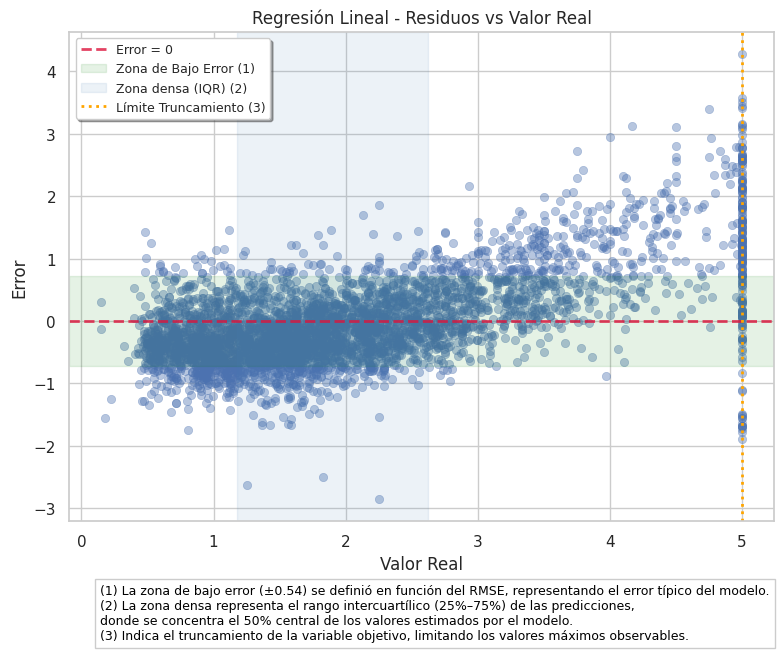

In [ ]:
sns.set(style="whitegrid")

residuos_lr = y_test - y_pred_lr
rmse_lr = np.sqrt(np.mean(residuos_lr**2))

plt.figure(figsize=(8,6))

# Scatter: Real vs Residuos
sns.scatterplot(
    x=y_test,
    y=residuos_lr,
    alpha=0.4,
    edgecolor=None
)

# Línea en error = 0
plt.axhline(
    0,
    linestyle="--",
    linewidth=2,
    color="crimson",
    alpha=0.8,
    label="Error = 0"
)

# Zona de bajo error (±RMSE) (1)
plt.axhspan(
    -rmse_lr,
    rmse_lr,
    color="green",
    alpha=0.1,
    label=f"Zona de Bajo Error (1)"
)

# Zona densa (IQR sobre valores REALES) (2)
q1_test = np.percentile(y_test, 25)
q3_test = np.percentile(y_test, 75)

plt.axvspan(
    q1_test,
    q3_test,
    color="steelblue",
    alpha=0.1,
    label="Zona densa (IQR) (2)"
)

# Línea de truncamiento (Vertical en este caso) (3)
plt.axvline(
    5,
    linestyle=":",
    linewidth=2,
    color="orange",
    label="Límite Truncamiento (3)"
)

# Labels
plt.xlabel("Valor Real")
plt.ylabel("Error")
plt.title("Regresión Lineal - Residuos vs Valor Real")

# Leyenda
plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=9)
plt.tight_layout()

# --- NOTAS AL PIE ---
notas_pie = (
    f"(1) La zona de bajo error (±{rmse_lr:.2f}) se definió en función del RMSE, representando el error típico del modelo.\n"
    f"(2) La zona densa representa el rango intercuartílico (25%–75%) de las predicciones,\ndonde se concentra el 50% central de los valores estimados por el modelo.\n"
    f"(3) Indica el truncamiento de la variable objetivo, limitando los valores máximos observables."
)

plt.figtext(0.135, -0.08, notas_pie_mlp, fontsize=9, color='black',
            ha='left', bbox=dict(facecolor='none', edgecolor='#CCCCCC'))

plt.show()

El gráfico revela una deficiencia estructural característica del modelo lineal.

Se observa que la varianza del error no es constante. A medida que el valor real de la vivienda aumenta, la dispersión de los residuos se expande significativamente, lo que indica que el modelo pierde fiabilidad conforme las propiedades son más costosas.

Nuevamente se hace presente el truncamiento artificial de los datos, al ser una regresión lineal el modelo intenta seguir una tendencia recta, pero al encontrarse con una acumulación masiva de datos "tope" en 5.0, los errores se disparan tanto en subestimación como en sobreestimación.

La ligera curvatura ascendente de la nube de puntos antes de llegar al truncamiento es otra instancia en la que se exterioriza que la relación real entre las variables es curva (no lineal). El modelo lineal, al ser rígido, deja este patrón "atrapado" en los residuos en lugar de aprenderlo.


#### **Regresión Lineal - Conclusión general del modelo**

Aunque logra capturar la tendencia central de los datos, el desempeño del modelo de Regresión Lineal presenta limitaciones debido a su rigidez matemática que le impide modelar las interacciones no lineales. Esto genera un subajuste (underfitting) que induce una mayor incertidumbre y una distribución de errores menos precisa en comparación con el modelo de Red Neuronal MLP.

Las principales deficiencias del modelo radican en su incapacidad para respetar los límites del dominio y las fronteras de los datos. Al carecer de funciones de activación, la regresión extrapola erróneamente hacia valores negativos en la gama baja y sobreestima los precios en la gama alta, ignorando el truncamiento artificial de la muestra. En definitiva, el modelo lineal resulta insuficiente al no poder adaptarse a la lógica del set de datos ni a las irregularidades estadísticas presentes en el mismo.

### **Conclusiones generales acerca de la no linealidad del aprendizaje**

Un modelo lineal (como la regresión lineal) solo puede representar relaciones del tipo: $y = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n$, es decir, combinaciones lineales de las variables.

En cambio, una red neuronal introduce no linealidad a través de las funciones de activación. Cada neurona realiza una transformación $z = \sum w_i x_i + b$
y luego aplica una función de activación que le otorga no linealidad $a = f(z)$. Si no existiera la función, múltiples capas de la red serían equivalentes a una sola transformación lineal, sn embargo, al aplicarlas la red puede capturar interacciones complejas entre variables  

Por lo expuesto, las no linealidades no se aprenden directamente como una fórmula explícita, sino que emergen de la composición de múltiples transformaciones lineales + funciones no lineales, permitiendo aproximar funciones complejas.

### **Extras**

#### **MLP - Guardado y carga del modelo**

Tras optimizar el modelo es fundamental implementar un metodo que permita su reutilización sin repetir el entrenamiento.

###### **Guardado del modelo**

Para utilizar el modelo en el futuro sin reentrenar, es imprescindible exportar tanto el MLP como el StandardScaler.

Las redes neuronales dependen estrictamente de que los datos de entrada mantengan la misma escala con la que fueron entrenadas. Guardar el escalador permite aplicar la misma transformación estadística a nuevas observaciones, garantizando que el modelo reciba la información en el formato correcto y mantenga su capacidad predictiva. Sin este componente, las predicciones con datos nuevos carecerían de validez técnica.

In [ ]:
# Defino los nombres de los archivos
model_filename = 'california_housing_mlp_model.pkl'
scaler_filename = 'california_housing_scaler_mlp.pkl'

# Guardo los objetos en el entorno local del notebook
joblib.dump(best_mlp, model_filename)
joblib.dump(scaler, scaler_filename)

print("Archivos guardados en el drive local.")

# Descargo los archivos a tu PC
files.download(model_filename)
files.download(scaler_filename)

print("Archivos descargados.")

Archivos guardados en el drive local.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Archivos descargados.


###### **Carga del modelo**

Para realizar predicciones con nuevos datos, se deben cargar ambos archivos serializados (.pkl). Es fundamental aplicar el método .transform() del escalador cargado a las nuevas entradas antes de pasarlas al modelo para asegurar que la red neuronal procese la información en la misma escala estadística con la que fue entrenada.

In [ ]:
# Subir el .pkl del entrenamiento y el escalado al directorio de trabajo del cuaderno de colab
# Cargo los archivos
loaded_model = joblib.load('best_mlp_model.pkl')
loaded_scaler = joblib.load('scaler_mlp.pkl')

# Aplico el mismo escalado a los datos nuevos a los que se aplique el modelo (X_new)
X_new_scaled = loaded_scaler.transform(X_new)

# Genero las predicciónes
predicciones = loaded_model.predict(X_new_scaled)